In [ ]:
!wget -q https://raw.githubusercontent.com/bahaa-budargham/engineering-of-alphabets/main/english_alphabet.json

In [ ]:
"""
EOA-43 vs Random-43 sentence-level sentiment on SST-2.
Single-file Colab script. Requires english_alphabet.json uploaded to /content/.

Compares a hand-crafted EOA letter encoder to a random-letter-vector
baseline (matched dimensionality, multiple random draws). Reports
per-draw paired t-tests combined via Stouffer's method, plus effect
size with standard error across draws.
"""
import json
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from datasets import load_dataset
from scipy.stats import ttest_rel, wilcoxon, combine_pvalues
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            letter_seqs[letter] = value["sequence"]
    elif isinstance(value, list):
        letter_seqs[key] = value

SEQ_LEN = len(next(iter(letter_seqs.values())))
print(f"Loaded {len(letter_seqs)} letters, sequence length {SEQ_LEN}")

# Fairness check: random baseline always covers all 26 letters, so if EOA
# is missing some, random gets wider coverage and the comparison is biased.
missing = [c for c in 'abcdefghijklmnopqrstuvwxyz' if c not in letter_seqs]
if missing:
    print(f"WARNING: EOA is missing {len(missing)} letters: {missing}")
    print("         Random baseline has wider coverage; interpret with care.")

gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    """Position x gematria weighted sum of letter sequences, normalized by word length."""
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        seq = seqs.get(ch)
        if seq is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += np.array(seq) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. Shared training vocabulary and labels
# ============================================================
print("Loading SST-2...")
dataset = load_dataset('nyu-mll/glue', 'sst2')
y_train = np.array([item['label'] for item in dataset['train']])
y_test = np.array([item['label'] for item in dataset['validation']])

train_vocab = set()
for item in dataset['train']:
    for w in item['sentence'].lower().split():
        clean = ''.join(c for c in w if c.isalpha())
        if clean and len(clean) >= 2:
            train_vocab.add(clean)
train_words = sorted(train_vocab)

print(f"Train: {len(y_train)} sentences, val: {len(y_test)} sentences")
print(f"Training vocabulary: {len(train_words)} words")

# ============================================================
# 3. Pipeline builder: scaler + word dict + sentence encoder
# ============================================================
def build_pipeline(seqs, name):
    """Fit StandardScaler on training-vocab word vectors, return a sentence encoder."""
    train_vecs = []
    valid_words = []
    for w in train_words:
        vec = encode_word(w, seqs)
        if vec is not None:
            train_vecs.append(vec)
            valid_words.append(w)
    train_vecs = np.array(train_vecs)

    scaler = StandardScaler().fit(train_vecs)
    # Reuse the already-computed raw vectors instead of re-encoding
    word_dict = {
        w: scaler.transform(train_vecs[i].reshape(1, -1)).flatten()
        for i, w in enumerate(valid_words)
    }

    # Standardized-space mean == zero vector (StandardScaler centers to 0)
    empty_vec = np.zeros(SEQ_LEN)

    def encode_sentence(text):
        vecs = []
        for w in text.lower().split():
            clean = ''.join(c for c in w if c.isalpha())
            if clean in word_dict:
                vecs.append(word_dict[clean])
        return np.mean(vecs, axis=0) if vecs else empty_vec

    print(f"  {name}: encoded {len(valid_words)}/{len(train_words)} vocab words")
    return encode_sentence


def encode_all(encode_sentence, split):
    return np.array([encode_sentence(item['sentence']) for item in dataset[split]])


# ============================================================
# 4. MLP runner
# ============================================================
def run_mlps(X_train, X_test, seeds):
    accs = []
    for seed in seeds:
        mlp = MLPClassifier(
            hidden_layer_sizes=(128,), activation='relu',
            max_iter=500, random_state=seed,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10,
        )
        mlp.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, mlp.predict(X_test)))
    return np.array(accs)


# ============================================================
# 5. EOA-43
# ============================================================
print("Building EOA-43 pipeline...")
eoa_encode = build_pipeline(letter_seqs, "EOA-43")
X_train_eoa = encode_all(eoa_encode, 'train')
X_test_eoa = encode_all(eoa_encode, 'validation')

# ============================================================
# 6. Random-43 with multiple draws
# ============================================================
N_RANDOM_DRAWS = 5
SEEDS = list(range(100, 120))  # 20 MLP seeds

print(f"Training EOA-43 ({len(SEEDS)} seeds)...")
t0 = time.time()
eoa_accs = run_mlps(X_train_eoa, X_test_eoa, SEEDS)
print(f"  EOA-43 done in {time.time() - t0:.1f}s, mean = {eoa_accs.mean():.4f}")

random_per_draw = []
print(f"Training Random-43 ({N_RANDOM_DRAWS} draws x {len(SEEDS)} seeds each)...")
t0 = time.time()
for draw in range(N_RANDOM_DRAWS):
    rng = np.random.RandomState(draw)
    rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in 'abcdefghijklmnopqrstuvwxyz'}
    rand_encode = build_pipeline(rand_seqs, f"Random-43 (draw {draw + 1})")
    X_train_rand = encode_all(rand_encode, 'train')
    X_test_rand = encode_all(rand_encode, 'validation')
    accs = run_mlps(X_train_rand, X_test_rand, SEEDS)
    random_per_draw.append(accs)
    print(f"  Draw {draw + 1}: mean = {accs.mean():.4f}, std = {accs.std():.4f}")
print(f"  Random done in {time.time() - t0:.1f}s")

# ============================================================
# 7. Results
# ============================================================
print("\n" + "=" * 60)
print("RESULTS (Sentence-Level SST-2)")
print("=" * 60)
print(f"EOA-43   : mean = {eoa_accs.mean():.4f}, std = {eoa_accs.std():.4f}")

rand_means = np.array([r.mean() for r in random_per_draw])
rand_pooled = np.concatenate(random_per_draw)
print(f"Random-43: per-draw mean of means = {rand_means.mean():.4f} +/- {rand_means.std():.4f}")
print(f"           pooled ({len(rand_pooled)} runs) = {rand_pooled.mean():.4f} +/- {rand_pooled.std():.4f}")

# Per-draw paired t-test, combined via Stouffer (tests are independent across draws)
pvals = [ttest_rel(eoa_accs, r).pvalue for r in random_per_draw]
_, p_combined = combine_pvalues(pvals, method='stouffer')

# Effect size: mean of per-draw (EOA - Random), SE across draws
mean_diffs = np.array([(eoa_accs - r).mean() for r in random_per_draw])
diff_se = mean_diffs.std() / np.sqrt(N_RANDOM_DRAWS)

print(f"\nPer-draw mean diff (EOA - Random): {mean_diffs}")
print(f"Combined (Stouffer) p-value: {p_combined:.4g}")
print(f"Effect size: {mean_diffs.mean():+.4f} +/- {diff_se:.4f} (SE over {N_RANDOM_DRAWS} draws)")

# Distribution-free sanity check on the first draw
_, p_w = wilcoxon(eoa_accs, random_per_draw[0])
print(f"Wilcoxon (EOA vs Random draw 1): p = {p_w:.4f}")

Loaded 26 letters, sequence length 43
Loading SST-2...


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train: 67349 sentences, val: 872 sentences
Training vocabulary: 14511 words
Building EOA-43 pipeline...


UFuncTypeError: Cannot cast ufunc 'add' output from dtype('O') to dtype('float64') with casting rule 'same_kind'

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'sample_data']


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'sample_data']


In [ ]:
"""
EOA-43 vs Random-43 sentence-level sentiment on SST-2.
Single-file Colab script. Requires english_alphabet.json uploaded to /content/.

Compares a hand-crafted EOA letter encoder to a random-letter-vector
baseline (matched dimensionality, multiple random draws). Reports
per-draw paired t-tests combined via Stouffer's method, plus effect
size with standard error across draws.
"""
import json
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from datasets import load_dataset
from scipy.stats import ttest_rel, wilcoxon, combine_pvalues
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def _coerce_sequence(raw_seq, label, expected_len):
    """Coerce a JSON sequence to a list of floats; return None on failure."""
    if not isinstance(raw_seq, (list, tuple)):
        print(f"WARNING: sequence for '{label}' is not a list (got {type(raw_seq).__name__}); skipping")
        return None
    try:
        seq = [float(x) for x in raw_seq]
    except (TypeError, ValueError) as e:
        print(f"WARNING: non-numeric values in sequence for '{label}': {e}; skipping")
        return None
    if len(seq) != expected_len:
        print(f"WARNING: sequence for '{label}' has length {len(seq)}, expected {expected_len}; skipping")
        return None
    return seq


with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

# Determine SEQ_LEN from the first valid sequence
_first_val = next(iter(raw_data.values()))
_first_seq = _first_val["sequence"] if isinstance(_first_val, dict) else _first_val
SEQ_LEN = len(_first_seq)
print(f"Sequence length: {SEQ_LEN}")

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            seq = _coerce_sequence(value["sequence"], letter, SEQ_LEN)
            if seq is not None:
                letter_seqs[letter] = seq
    elif isinstance(value, list):
        seq = _coerce_sequence(value, key, SEQ_LEN)
        if seq is not None:
            letter_seqs[key] = seq

print(f"Loaded {len(letter_seqs)} letters (of 26)")

# Fairness check
missing = [c for c in 'abcdefghijklmnopqrstuvwxyz' if c not in letter_seqs]
if missing:
    print(f"WARNING: missing/invalid letters: {missing}")

gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    """Position x gematria weighted sum of letter sequences, normalized by word length."""
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        seq = seqs.get(ch)
        if seq is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            # dtype=float defends against any object-dtype that slipped through
            vec += np.asarray(seq, dtype=float) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. Shared training vocabulary and labels
# ============================================================
print("Loading SST-2...")
dataset = load_dataset('nyu-mll/glue', 'sst2')
y_train = np.array([item['label'] for item in dataset['train']])
y_test = np.array([item['label'] for item in dataset['validation']])

train_vocab = set()
for item in dataset['train']:
    for w in item['sentence'].lower().split():
        clean = ''.join(c for c in w if c.isalpha())
        if clean and len(clean) >= 2:
            train_vocab.add(clean)
train_words = sorted(train_vocab)

print(f"Train: {len(y_train)} sentences, val: {len(y_test)} sentences")
print(f"Training vocabulary: {len(train_words)} words")

# ============================================================
# 3. Pipeline builder: scaler + word dict + sentence encoder
# ============================================================
def build_pipeline(seqs, name):
    """Fit StandardScaler on training-vocab word vectors, return a sentence encoder."""
    train_vecs = []
    valid_words = []
    for w in train_words:
        vec = encode_word(w, seqs)
        if vec is not None:
            train_vecs.append(vec)
            valid_words.append(w)
    train_vecs = np.array(train_vecs)

    scaler = StandardScaler().fit(train_vecs)
    # Reuse the already-computed raw vectors instead of re-encoding
    word_dict = {
        w: scaler.transform(train_vecs[i].reshape(1, -1)).flatten()
        for i, w in enumerate(valid_words)
    }

    # Standardized-space mean == zero vector (StandardScaler centers to 0)
    empty_vec = np.zeros(SEQ_LEN)

    def encode_sentence(text):
        vecs = []
        for w in text.lower().split():
            clean = ''.join(c for c in w if c.isalpha())
            if clean in word_dict:
                vecs.append(word_dict[clean])
        return np.mean(vecs, axis=0) if vecs else empty_vec

    print(f"  {name}: encoded {len(valid_words)}/{len(train_words)} vocab words")
    return encode_sentence


def encode_all(encode_sentence, split):
    return np.array([encode_sentence(item['sentence']) for item in dataset[split]])


# ============================================================
# 4. MLP runner
# ============================================================
def run_mlps(X_train, X_test, seeds):
    accs = []
    for seed in seeds:
        mlp = MLPClassifier(
            hidden_layer_sizes=(128,), activation='relu',
            max_iter=500, random_state=seed,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10,
        )
        mlp.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, mlp.predict(X_test)))
    return np.array(accs)


# ============================================================
# 5. EOA-43
# ============================================================
print("Building EOA-43 pipeline...")
eoa_encode = build_pipeline(letter_seqs, "EOA-43")
X_train_eoa = encode_all(eoa_encode, 'train')
X_test_eoa = encode_all(eoa_encode, 'validation')

# ============================================================
# 6. Random-43 with multiple draws
# ============================================================
N_RANDOM_DRAWS = 5
SEEDS = list(range(100, 120))  # 20 MLP seeds

print(f"Training EOA-43 ({len(SEEDS)} seeds)...")
t0 = time.time()
eoa_accs = run_mlps(X_train_eoa, X_test_eoa, SEEDS)
print(f"  EOA-43 done in {time.time() - t0:.1f}s, mean = {eoa_accs.mean():.4f}")

random_per_draw = []
print(f"Training Random-43 ({N_RANDOM_DRAWS} draws x {len(SEEDS)} seeds each)...")
t0 = time.time()
for draw in range(N_RANDOM_DRAWS):
    rng = np.random.RandomState(draw)
    rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in 'abcdefghijklmnopqrstuvwxyz'}
    rand_encode = build_pipeline(rand_seqs, f"Random-43 (draw {draw + 1})")
    X_train_rand = encode_all(rand_encode, 'train')
    X_test_rand = encode_all(rand_encode, 'validation')
    accs = run_mlps(X_train_rand, X_test_rand, SEEDS)
    random_per_draw.append(accs)
    print(f"  Draw {draw + 1}: mean = {accs.mean():.4f}, std = {accs.std():.4f}")
print(f"  Random done in {time.time() - t0:.1f}s")

# ============================================================
# 7. Results
# ============================================================
print("\n" + "=" * 60)
print("RESULTS (Sentence-Level SST-2)")
print("=" * 60)
print(f"EOA-43   : mean = {eoa_accs.mean():.4f}, std = {eoa_accs.std():.4f}")

rand_means = np.array([r.mean() for r in random_per_draw])
rand_pooled = np.concatenate(random_per_draw)
print(f"Random-43: per-draw mean of means = {rand_means.mean():.4f} +/- {rand_means.std():.4f}")
print(f"           pooled ({len(rand_pooled)} runs) = {rand_pooled.mean():.4f} +/- {rand_pooled.std():.4f}")

# Per-draw paired t-test, combined via Stouffer (tests are independent across draws)
pvals = [ttest_rel(eoa_accs, r).pvalue for r in random_per_draw]
_, p_combined = combine_pvalues(pvals, method='stouffer')

# Effect size: mean of per-draw (EOA - Random), SE across draws
mean_diffs = np.array([(eoa_accs - r).mean() for r in random_per_draw])
diff_se = mean_diffs.std() / np.sqrt(N_RANDOM_DRAWS)

print(f"\nPer-draw mean diff (EOA - Random): {mean_diffs}")
print(f"Combined (Stouffer) p-value: {p_combined:.4g}")
print(f"Effect size: {mean_diffs.mean():+.4f} +/- {diff_se:.4f} (SE over {N_RANDOM_DRAWS} draws)")

# Distribution-free sanity check on the first draw
_, p_w = wilcoxon(eoa_accs, random_per_draw[0])
print(f"Wilcoxon (EOA vs Random draw 1): p = {p_w:.4f}")

Sequence length: 43
Loaded 26 letters (of 26)
Loading SST-2...
Train: 67349 sentences, val: 872 sentences
Training vocabulary: 14511 words
Building EOA-43 pipeline...
  EOA-43: encoded 14511/14511 vocab words
Training EOA-43 (20 seeds)...
  EOA-43 done in 126.8s, mean = 0.5364
Training Random-43 (5 draws x 20 seeds each)...
  Random-43 (draw 1): encoded 14511/14511 vocab words
  Draw 1: mean = 0.5904, std = 0.0086
  Random-43 (draw 2): encoded 14511/14511 vocab words
  Draw 2: mean = 0.5837, std = 0.0097
  Random-43 (draw 3): encoded 14511/14511 vocab words
  Draw 3: mean = 0.5900, std = 0.0083
  Random-43 (draw 4): encoded 14511/14511 vocab words
  Draw 4: mean = 0.5840, std = 0.0081
  Random-43 (draw 5): encoded 14511/14511 vocab words
  Draw 5: mean = 0.5862, std = 0.0103
  Random done in 1646.6s

RESULTS (Sentence-Level SST-2)
EOA-43   : mean = 0.5364, std = 0.0071
Random-43: per-draw mean of means = 0.5868 +/- 0.0029
           pooled (100 runs) = 0.5868 +/- 0.0095

Per-draw mean 

In [ ]:
from numpy.linalg import svd
sv = np.linalg.svd(X_train_eoa, compute_uv=False)
print(f"EOA singular values: top 10 = {sv[:10].round(2)}")
print(f"EOA effective rank (90% variance): {(sv.cumsum() / sv.sum() < 0.9).sum() + 1}")

sv_r = np.linalg.svd(X_train_rand, compute_uv=False)
print(f"Random singular values: top 10 = {sv_r[:10].round(2)}")
print(f"Random effective rank (90% variance): {(sv_r.cumsum() / sv_r.sum() < 0.9).sum() + 1}")

EOA singular values: top 10 = [1.05938e+03 1.34640e+02 3.36400e+01 1.10900e+01 3.85000e+00 8.30000e-01
 2.40000e-01 1.00000e-02 0.00000e+00 0.00000e+00]
EOA effective rank (90% variance): 2
Random singular values: top 10 = [403.76 349.68 337.16 291.27 234.84 227.88 202.02 181.05 141.13 125.31]
Random effective rank (90% variance): 16


Sequence length: 43
Loaded 26 letters (of 26)
Loading SST-2...
Train: 67349 sentences, val: 872 sentences
Training vocabulary: 14511 words
Building EOA-43 pipeline...
  EOA-43: encoded 14511/14511 vocab words
Training EOA-43 MLPs (20 seeds)...
  EOA-43 done in 135.7s, clean acc = 0.5364

--- PCA-2 diagnostic ---
EOA-43 (43-dim):  0.5364
EOA-PCA-2 (2-dim): 0.5450
  -> Signal is in top-2 components; the other 41 dims are noise (confirms rank-collapse)

Pre-computing noisy validation sentences...
Evaluating EOA-43 on noisy validation...
  EOA-43 noise eval done in 1.8s

Building Random-43 pipelines (5 draws)...

Draw 1/5:
  Random-43 (draw 1): encoded 14511/14511 vocab words
  clean acc = 0.5904

Draw 2/5:
  Random-43 (draw 2): encoded 14511/14511 vocab words
  clean acc = 0.5837

Draw 3/5:
  Random-43 (draw 3): encoded 14511/14511 vocab words
  clean acc = 0.5900

Draw 4/5:
  Random-43 (draw 4): encoded 14511/14511 vocab words
  clean acc = 0.5840

Draw 5/5:
  Random-43 (draw 5): encoded

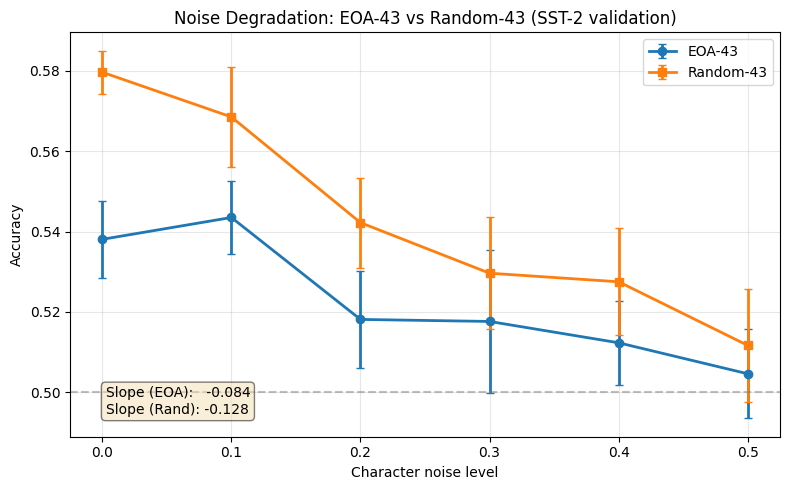


Plot saved to /content/noise_degradation.png


In [ ]:
"""
Noise degradation + PCA-2 diagnostic for EOA-43 vs Random-43 on SST-2.

Self-contained Colab script. Reuses the previous experimental design
(sentence-level, mean-pooled, 20 seeds, 5 random draws) and adds:
  1. PCA-2 reduction of EOA to test the rank-collapse hypothesis
  2. Character-level noise (0%, 10%, 20%, 30%, 40%, 50%) on validation
  3. Degradation curve plotting

Noise is generated ONCE per (sentence, level, copy) and applied to both
pipelines identically, so any difference in degradation is due to the
encoding, not the noise content.
"""
import json
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def _coerce_sequence(raw_seq, label, expected_len):
    if not isinstance(raw_seq, (list, tuple)):
        print(f"WARNING: sequence for '{label}' is not a list; skipping")
        return None
    try:
        seq = [float(x) for x in raw_seq]
    except (TypeError, ValueError) as e:
        print(f"WARNING: non-numeric values in sequence for '{label}': {e}; skipping")
        return None
    if len(seq) != expected_len:
        print(f"WARNING: sequence for '{label}' has length {len(seq)}, expected {expected_len}; skipping")
        return None
    return seq


with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

_first_val = next(iter(raw_data.values()))
_first_seq = _first_val["sequence"] if isinstance(_first_val, dict) else _first_val
SEQ_LEN = len(_first_seq)
print(f"Sequence length: {SEQ_LEN}")

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            seq = _coerce_sequence(value["sequence"], letter, SEQ_LEN)
            if seq is not None:
                letter_seqs[letter] = seq
    elif isinstance(value, list):
        seq = _coerce_sequence(value, key, SEQ_LEN)
        if seq is not None:
            letter_seqs[key] = seq

print(f"Loaded {len(letter_seqs)} letters (of 26)")
gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        seq = seqs.get(ch)
        if seq is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += np.asarray(seq, dtype=float) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. Load SST-2 and build shared vocabulary
# ============================================================
print("Loading SST-2...")
dataset = load_dataset('nyu-mll/glue', 'sst2')
y_train = np.array([item['label'] for item in dataset['train']])
y_test = np.array([item['label'] for item in dataset['validation']])
val_sentences = [item['sentence'] for item in dataset['validation']]

train_vocab = set()
for item in dataset['train']:
    for w in item['sentence'].lower().split():
        clean = ''.join(c for c in w if c.isalpha())
        if clean and len(clean) >= 2:
            train_vocab.add(clean)
train_words = sorted(train_vocab)

print(f"Train: {len(y_train)} sentences, val: {len(y_test)} sentences")
print(f"Training vocabulary: {len(train_words)} words")


# ============================================================
# 3. Pipeline builder
# ============================================================
def build_pipeline(seqs, name):
    train_vecs = []
    valid_words = []
    for w in train_words:
        vec = encode_word(w, seqs)
        if vec is not None:
            train_vecs.append(vec)
            valid_words.append(w)
    train_vecs = np.array(train_vecs)

    scaler = StandardScaler().fit(train_vecs)
    word_dict = {
        w: scaler.transform(train_vecs[i].reshape(1, -1)).flatten()
        for i, w in enumerate(valid_words)
    }
    empty_vec = np.zeros(SEQ_LEN)

    def encode_sentence(text):
        vecs = []
        for w in text.lower().split():
            clean = ''.join(c for c in w if c.isalpha())
            if clean in word_dict:
                vecs.append(word_dict[clean])
        return np.mean(vecs, axis=0) if vecs else empty_vec

    print(f"  {name}: encoded {len(valid_words)}/{len(train_words)} vocab words")
    return encode_sentence


def encode_all(encode_sentence, split):
    return np.array([encode_sentence(item['sentence']) for item in dataset[split]])


# ============================================================
# 4. MLP runner (returns models so we can reuse them)
# ============================================================
def train_mlps(X_train, X_test, seeds):
    accs, models = [], []
    for seed in seeds:
        mlp = MLPClassifier(
            hidden_layer_sizes=(128,), activation='relu',
            max_iter=500, random_state=seed,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10,
        )
        mlp.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, mlp.predict(X_test)))
        models.append(mlp)
    return np.array(accs), models


# ============================================================
# 5. Configuration
# ============================================================
SEEDS = list(range(100, 120))        # 20 MLP seeds
N_RANDOM_DRAWS = 5
NOISE_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
N_NOISE_COPIES = 5
ALPHABET = list('abcdefghijklmnopqrstuvwxyz')


# ============================================================
# 6. Noise generator (uniform random character replacement)
# ============================================================
def add_noise(text, p, rng):
    """Replace p-fraction of alphabetic chars with random letters."""
    chars = list(text)
    alpha_idxs = [i for i, c in enumerate(chars) if c.isalpha()]
    if not alpha_idxs:
        return text
    n_noise = max(1, int(len(alpha_idxs) * p))
    idxs = rng.choice(alpha_idxs, min(n_noise, len(alpha_idxs)), replace=False)
    for i in idxs:
        chars[i] = rng.choice(ALPHABET)
    return ''.join(chars)


def precompute_noisy(sentences, noise_levels, n_copies, base_seed=42):
    """Pre-generate all noisy versions. noisy[level][copy] = list of noisy sentences."""
    noisy = {}
    for p in noise_levels:
        copies = []
        for copy in range(n_copies):
            rng = np.random.RandomState(base_seed + int(p * 1000) + copy * 100)
            copies.append([add_noise(s, p, rng) for s in sentences])
        noisy[p] = copies
    return noisy


def evaluate_noise(encode_sentence, models, noisy_val, noise_levels):
    """Returns dict: noise_level -> flat array of accuracies (n_seeds * n_copies)."""
    results = {}
    for p in noise_levels:
        accs = []
        for copy_sentences in noisy_val[p]:
            X_noisy = np.array([encode_sentence(s) for s in copy_sentences])
            for mlp in models:
                accs.append(accuracy_score(y_test, mlp.predict(X_noisy)))
        results[p] = np.array(accs)
    return results


# ============================================================
# 7. EOA-43: train, PCA-2 diagnostic, noise evaluation
# ============================================================
print("Building EOA-43 pipeline...")
eoa_encode = build_pipeline(letter_seqs, "EOA-43")
X_train_eoa = encode_all(eoa_encode, 'train')
X_test_eoa = encode_all(eoa_encode, 'validation')

print(f"Training EOA-43 MLPs ({len(SEEDS)} seeds)...")
t0 = time.time()
eoa_accs, eoa_models = train_mlps(X_train_eoa, X_test_eoa, SEEDS)
print(f"  EOA-43 done in {time.time() - t0:.1f}s, clean acc = {eoa_accs.mean():.4f}")

# PCA-2 diagnostic
print("\n--- PCA-2 diagnostic ---")
pca = PCA(n_components=2).fit(X_train_eoa)
X_train_eoa_pca = pca.transform(X_train_eoa)
X_test_eoa_pca = pca.transform(X_test_eoa)
eoa_pca_accs, _ = train_mlps(X_train_eoa_pca, X_test_eoa_pca, SEEDS)
print(f"EOA-43 (43-dim):  {eoa_accs.mean():.4f}")
print(f"EOA-PCA-2 (2-dim): {eoa_pca_accs.mean():.4f}")
if eoa_pca_accs.mean() >= eoa_accs.mean() - 0.01:
    print("  -> Signal is in top-2 components; the other 41 dims are noise (confirms rank-collapse)")
else:
    print("  -> Distributed signal lost in PCA reduction (more nuanced story)")

# Pre-compute noisy validation (same noise used for both pipelines)
print("\nPre-computing noisy validation sentences...")
noisy_val = precompute_noisy(val_sentences, NOISE_LEVELS, N_NOISE_COPIES)

# EOA noise evaluation
print("Evaluating EOA-43 on noisy validation...")
t0 = time.time()
eoa_noise = evaluate_noise(eoa_encode, eoa_models, noisy_val, NOISE_LEVELS)
print(f"  EOA-43 noise eval done in {time.time() - t0:.1f}s")


# ============================================================
# 8. Random-43: 5 draws, train, noise evaluation, average
# ============================================================
print(f"\nBuilding Random-43 pipelines ({N_RANDOM_DRAWS} draws)...")
random_noise_per_draw = []
random_clean_accs = []
for draw in range(N_RANDOM_DRAWS):
    print(f"\nDraw {draw + 1}/{N_RANDOM_DRAWS}:")
    rng = np.random.RandomState(draw)
    rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in ALPHABET}
    rand_encode = build_pipeline(rand_seqs, f"Random-43 (draw {draw + 1})")
    X_train_rand = encode_all(rand_encode, 'train')
    X_test_rand = encode_all(rand_encode, 'validation')

    accs, models = train_mlps(X_train_rand, X_test_rand, SEEDS)
    random_clean_accs.append(accs.mean())
    res = evaluate_noise(rand_encode, models, noisy_val, NOISE_LEVELS)
    random_noise_per_draw.append(res)
    print(f"  clean acc = {accs.mean():.4f}")

# Average across random draws
random_noise_avg = {p: np.mean([r[p] for r in random_noise_per_draw], axis=0)
                    for p in NOISE_LEVELS}


# ============================================================
# 9. Report
# ============================================================
print("\n" + "=" * 60)
print("CLEAN ACCURACY (recomputed for verification)")
print("=" * 60)
print(f"EOA-43   : {eoa_accs.mean():.4f} +/- {eoa_accs.std():.4f}")
print(f"Random-43: {np.mean(random_clean_accs):.4f} +/- {np.std(random_clean_accs):.4f}")

print("\n" + "=" * 60)
print("NOISE DEGRADATION (mean accuracy, 20 seeds x 5 copies)")
print("=" * 60)
print(f"{'Noise':>8} | {'EOA-43':>8} | {'Random-43':>10} | {'Gap':>8}")
print("-" * 60)
for p in NOISE_LEVELS:
    eoa_m = eoa_noise[p].mean()
    rand_m = random_noise_avg[p].mean()
    print(f"{p:>7.0%} | {eoa_m:>8.4f} | {rand_m:>10.4f} | {eoa_m - rand_m:>+8.4f}")

# Linear slopes (noise=0.1..0.5)
p_fit = NOISE_LEVELS[1:]
eoa_slope = np.polyfit(p_fit, [eoa_noise[p].mean() for p in p_fit], 1)[0]
rand_slope = np.polyfit(p_fit, [random_noise_avg[p].mean() for p in p_fit], 1)[0]
print(f"\nSlope (EOA,   10%-50%): {eoa_slope:+.4f} per unit noise")
print(f"Slope (Random, 10%-50%): {rand_slope:+.4f} per unit noise")
if eoa_slope < rand_slope:
    print("-> EOA degrades faster than Random (consistent with rank-collapse)")
else:
    print("-> EOA degrades at similar or slower rate than Random (unexpected)")

# At-noise-50% paired test
from scipy.stats import ttest_rel
_, p_at_50 = ttest_rel(eoa_noise[0.5], random_noise_avg[0.5])
print(f"\nt-test at 50% noise: p = {p_at_50:.4g}")


# ============================================================
# 10. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
eoa_means = [eoa_noise[p].mean() for p in NOISE_LEVELS]
eoa_stds = [eoa_noise[p].std() for p in NOISE_LEVELS]
rand_means = [random_noise_avg[p].mean() for p in NOISE_LEVELS]
rand_stds = [random_noise_avg[p].std() for p in NOISE_LEVELS]

ax.errorbar(NOISE_LEVELS, eoa_means, yerr=eoa_stds, marker='o', label='EOA-43',
            capsize=3, linewidth=2)
ax.errorbar(NOISE_LEVELS, rand_means, yerr=rand_stds, marker='s', label='Random-43',
            capsize=3, linewidth=2)
ax.set_xlabel('Character noise level')
ax.set_ylabel('Accuracy')
ax.set_title('Noise Degradation: EOA-43 vs Random-43 (SST-2 validation)')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='chance')

ax.text(0.05, 0.05,
        f'Slope (EOA):   {eoa_slope:+.3f}\nSlope (Rand): {rand_slope:+.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/content/noise_degradation.png', dpi=120)
plt.show()
print("\nPlot saved to /content/noise_degradation.png")

In [ ]:
"""
WordSim-353 semantic similarity test for EOA-43 vs Random-43.

Tests whether EOA-encoded word vectors predict human similarity judgments.
Computes Spearman rank correlation between cosine similarity (EOA or Random)
and the human mean score from WordSim-353.

Random baseline: 5 draws, mean +/- std of Spearman rho.
If EOA's rho is within random's range, the encoding has no measurable
semantic content. If it's significantly above, EOA captures something.
"""
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def _coerce_sequence(raw_seq, label, expected_len):
    if not isinstance(raw_seq, (list, tuple)):
        print(f"WARNING: sequence for '{label}' is not a list; skipping")
        return None
    try:
        seq = [float(x) for x in raw_seq]
    except (TypeError, ValueError) as e:
        print(f"WARNING: non-numeric values in sequence for '{label}': {e}; skipping")
        return None
    if len(seq) != expected_len:
        print(f"WARNING: sequence for '{label}' has length {len(seq)}, expected {expected_len}; skipping")
        return None
    return seq


with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

_first_val = next(iter(raw_data.values()))
_first_seq = _first_val["sequence"] if isinstance(_first_val, dict) else _first_val
SEQ_LEN = len(_first_seq)
print(f"Sequence length: {SEQ_LEN}")

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            seq = _coerce_sequence(value["sequence"], letter, SEQ_LEN)
            if seq is not None:
                letter_seqs[letter] = seq
    elif isinstance(value, list):
        seq = _coerce_sequence(value, key, SEQ_LEN)
        if seq is not None:
            letter_seqs[key] = seq

print(f"Loaded {len(letter_seqs)} letters (of 26)")
gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    """Position x gematria weighted sum of letter sequences, normalized by word length."""
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        s = seqs.get(ch)
        if s is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += np.asarray(s, dtype=float) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. Load WordSim-353
# ============================================================
df = pd.read_csv('/content/wordsim353_combined.csv')
print(f"Loaded {len(df)} word pairs")
print(f"Columns: {df.columns.tolist()}")

col_w1 = 'Word 1'
col_w2 = 'Word 2'
col_score = 'Human (mean)'


# ============================================================
# 3. Build word vectors from any letter-sequence set
# ============================================================
def build_word_vecs(seqs, unique_words):
    """Encode all unique words, fit StandardScaler, return dict {word: scaled_vec}."""
    raw_vecs = []
    valid_words = []
    for w in unique_words:
        v = encode_word(w, seqs)
        if v is not None:
            raw_vecs.append(v)
            valid_words.append(w)
    raw_vecs = np.array(raw_vecs)
    scaler = StandardScaler().fit(raw_vecs)
    return {
        w: scaler.transform(raw_vecs[i].reshape(1, -1)).flatten()
        for i, w in enumerate(valid_words)
    }, len(valid_words), len(unique_words)


# ============================================================
# 4. Compute Spearman rho on WordSim-353
# ============================================================
def compute_rho(word_vecs, df):
    """Compute Spearman correlation between cosine sims and human scores."""
    sims, scores, missing = [], [], 0
    for _, row in df.iterrows():
        w1, w2, s = row[col_w1], row[col_w2], row[col_score]
        if w1 in word_vecs and w2 in word_vecs:
            sim = 1 - cosine(word_vecs[w1], word_vecs[w2])
            sims.append(sim)
            scores.append(s)
        else:
            missing += 1
    rho, pval = spearmanr(sims, scores)
    return rho, pval, len(sims), missing


# ============================================================
# 5. EOA-43
# ============================================================
unique_words = set(df[col_w1].tolist() + df[col_w2].tolist())
print(f"Unique words: {len(unique_words)}")

print("\nBuilding EOA-43 word vectors...")
eoa_vecs, eoa_valid, eoa_total = build_word_vecs(letter_seqs, unique_words)
print(f"  Encoded {eoa_valid}/{eoa_total} words")

eoa_rho, eoa_p, eoa_pairs, eoa_missing = compute_rho(eoa_vecs, df)
print(f"  Pairs evaluated: {eoa_pairs}/{len(df)} (missing: {eoa_missing})")
print(f"  EOA-43 Spearman rho = {eoa_rho:.4f}, p = {eoa_p:.4g}")


# ============================================================
# 6. Random-43 baseline (multiple draws)
# ============================================================
N_RANDOM_DRAWS = 5
ALPHABET = list('abcdefghijklmnopqrstuvwxyz')

random_rhos = []
random_pvals = []
print(f"\nBuilding Random-43 baselines ({N_RANDOM_DRAWS} draws)...")
for draw in range(N_RANDOM_DRAWS):
    rng = np.random.RandomState(draw)
    rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in ALPHABET}
    rand_vecs, rand_valid, rand_total = build_word_vecs(rand_seqs, unique_words)
    rho, pval, pairs, missing = compute_rho(rand_vecs, df)
    random_rhos.append(rho)
    random_pvals.append(pval)
    print(f"  Draw {draw + 1}: rho = {rho:+.4f}, p = {pval:.4f} "
          f"(encoded {rand_valid}/{rand_total}, pairs {pairs}/{len(df)})")


# ============================================================
# 7. Report
# ============================================================
print("\n" + "=" * 60)
print("RESULTS (WordSim-353 Spearman correlation)")
print("=" * 60)
print(f"EOA-43   : rho = {eoa_rho:+.4f}, p = {eoa_p:.4g}")

random_rhos = np.array(random_rhos)
print(f"Random-43: mean rho = {random_rhos.mean():+.4f} +/- {random_rhos.std():.4f}  "
      f"(range [{random_rhos.min():+.4f}, {random_rhos.max():+.4f}])")

# Z-test: is EOA outside the random distribution?
if random_rhos.std() > 0:
    z = (eoa_rho - random_rhos.mean()) / random_rhos.std()
    print(f"\nZ-score (EOA vs random distribution): {z:+.2f}")
    if abs(z) > 2:
        print("  -> EOA is significantly different from random baseline")
    else:
        print("  -> EOA is within random's noise range (no detectable semantic signal)")

# Sign test
sign = sum(r > 0 for r in random_rhos)
print(f"Random draws with rho > 0: {sign}/{N_RANDOM_DRAWS}")

# Reference points for context
print("\nReference points (published):")
print("  GloVe:    rho ~ 0.65-0.70")
print("  word2vec: rho ~ 0.65-0.70")
print("  BERT:     rho ~ 0.70")
print("  Random:   rho ~ 0.0")

Sequence length: 43
Loaded 26 letters (of 26)
Loaded 353 word pairs
Columns: ['Word 1', 'Word 2', 'Human (mean)']
Unique words: 437

Building EOA-43 word vectors...
  Encoded 437/437 words
  Pairs evaluated: 353/353 (missing: 0)
  EOA-43 Spearman rho = 0.0071, p = 0.8937

Building Random-43 baselines (5 draws)...
  Draw 1: rho = -0.0088, p = 0.8695 (encoded 437/437, pairs 353/353)
  Draw 2: rho = +0.0750, p = 0.1596 (encoded 437/437, pairs 353/353)
  Draw 3: rho = +0.0142, p = 0.7898 (encoded 437/437, pairs 353/353)
  Draw 4: rho = -0.0053, p = 0.9216 (encoded 437/437, pairs 353/353)
  Draw 5: rho = +0.0431, p = 0.4198 (encoded 437/437, pairs 353/353)

RESULTS (WordSim-353 Spearman correlation)
EOA-43   : rho = +0.0071, p = 0.8937
Random-43: mean rho = +0.0237 +/- 0.0316  (range [-0.0088, +0.0750])

Z-score (EOA vs random distribution): -0.52
  -> EOA is within random's noise range (no detectable semantic signal)
Random draws with rho > 0: 3/5

Reference points (published):
  GloVe:   

In [ ]:
"""
Test 8: One-character edit continuity for EOA-43 vs Random-43.

Tests whether single-character edits to a word produce similar vectors.
30 hand-picked CVC edit pairs at all three positions.

Important: with EOA's effective rank of 2, ALL word vectors are nearly
parallel, so EOA will likely show high mean cosine similarity — but this
is the signature of degeneracy, not orthographic continuity. The variance
comparison is the diagnostic: low EOA variance = rank collapse, not
good structure.
"""
import json
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cosine
from scipy.stats import ttest_rel
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def _coerce_sequence(raw_seq, label, expected_len):
    if not isinstance(raw_seq, (list, tuple)):
        print(f"WARNING: sequence for '{label}' is not a list; skipping")
        return None
    try:
        seq = [float(x) for x in raw_seq]
    except (TypeError, ValueError) as e:
        print(f"WARNING: non-numeric values in sequence for '{label}': {e}; skipping")
        return None
    if len(seq) != expected_len:
        print(f"WARNING: sequence for '{label}' has length {len(seq)}, expected {expected_len}; skipping")
        return None
    return seq


with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

_first_val = next(iter(raw_data.values()))
_first_seq = _first_val["sequence"] if isinstance(_first_val, dict) else _first_val
SEQ_LEN = len(_first_seq)
print(f"Sequence length: {SEQ_LEN}")

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            seq = _coerce_sequence(value["sequence"], letter, SEQ_LEN)
            if seq is not None:
                letter_seqs[letter] = seq
    elif isinstance(value, list):
        seq = _coerce_sequence(value, key, SEQ_LEN)
        if seq is not None:
            letter_seqs[key] = seq

print(f"Loaded {len(letter_seqs)} letters (of 26)")
gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        s = seqs.get(ch)
        if s is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += np.asarray(s, dtype=float) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. One-character edit word pairs
# ============================================================
edit_pairs = [
    ("cat", "bat"), ("cat", "cot"), ("cat", "cap"),
    ("dog", "dig"), ("dog", "fog"), ("dog", "dot"),
    ("run", "sun"), ("run", "ran"), ("run", "rut"),
    ("big", "bag"), ("big", "bug"), ("big", "bid"),
    ("hot", "hat"), ("hot", "hit"), ("hot", "hop"),
    ("bed", "bad"), ("bed", "bud"), ("bed", "bet"),
    ("man", "can"), ("man", "men"), ("man", "map"),
    ("cup", "cap"), ("cup", "cub"), ("cup", "cut"),
    ("sit", "sat"), ("sit", "sin"), ("sit", "sip"),
    ("top", "tip"), ("top", "tap"), ("top", "tot"),
]

print(f"Edit pairs: {len(edit_pairs)}")


# ============================================================
# 3. Build vectors for any letter-sequence set
# ============================================================
def build_word_vecs(seqs, words):
    """Encode words, fit StandardScaler, return {word: scaled_vec}."""
    raw_vecs = []
    valid_words = []
    for w in words:
        v = encode_word(w, seqs)
        if v is not None:
            raw_vecs.append(v)
            valid_words.append(w)
    raw_vecs = np.array(raw_vecs)
    scaler = StandardScaler().fit(raw_vecs)
    return {
        w: scaler.transform(raw_vecs[i].reshape(1, -1)).flatten()
        for i, w in enumerate(valid_words)
    }


# ============================================================
# 4. EOA-43
# ============================================================
unique_words = sorted(set(w for pair in edit_pairs for w in pair))
print(f"Unique words: {len(unique_words)}")

print("\nBuilding EOA-43 word vectors...")
eoa_vecs = build_word_vecs(letter_seqs, unique_words)

eoa_sims = []
for w1, w2 in edit_pairs:
    if w1 in eoa_vecs and w2 in eoa_vecs:
        eoa_sims.append(1 - cosine(eoa_vecs[w1], eoa_vecs[w2]))
eoa_sims = np.array(eoa_sims)


# ============================================================
# 5. Random-43 baseline (multiple draws)
# ============================================================
N_RANDOM_DRAWS = 5
ALPHABET = list('abcdefghijklmnopqrstuvwxyz')

random_sims_all = []  # shape (N_DRAWS, N_PAIRS)
print(f"Building Random-43 baselines ({N_RANDOM_DRAWS} draws)...")
for draw in range(N_RANDOM_DRAWS):
    rng = np.random.RandomState(draw)
    rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in ALPHABET}
    rand_vecs = build_word_vecs(rand_seqs, unique_words)
    sims = [1 - cosine(rand_vecs[w1], rand_vecs[w2])
            for w1, w2 in edit_pairs
            if w1 in rand_vecs and w2 in rand_vecs]
    random_sims_all.append(np.array(sims))
    print(f"  Draw {draw + 1}: mean sim = {np.mean(sims):.4f}, std = {np.std(sims):.4f}")


# ============================================================
# 6. Report
# ============================================================
print("\n" + "=" * 60)
print("ONE-CHARACTER EDIT CONTINUITY (Cosine Similarity)")
print("=" * 60)
print(f"EOA-43   : mean = {eoa_sims.mean():.4f}, std = {eoa_sims.std():.4f}, "
      f"var = {eoa_sims.var():.4f}")

random_pooled = np.concatenate(random_sims_all)
random_per_pair = np.array(random_sims_all).mean(axis=0)
print(f"Random-43: mean = {random_pooled.mean():.4f}, std = {random_pooled.std():.4f}, "
      f"var = {random_pooled.var():.4f}")
print(f"           (pooled {N_RANDOM_DRAWS} draws x {len(edit_pairs)} pairs)")


# Paired t-test (per-pair: EOA vs Random mean)
t, p = ttest_rel(eoa_sims, random_per_pair)
print(f"\nPaired t-test (EOA vs Random, per-pair): t = {t:.3f}, p = {p:.4g}")


# Interpretation — the variance is the diagnostic
eoa_mean, eoa_var = eoa_sims.mean(), eoa_sims.var()
rand_mean, rand_var = random_pooled.mean(), random_pooled.var()

print("\n--- Interpretation ---")
if eoa_mean > rand_mean and eoa_var < rand_var:
    print("EOA has HIGHER mean but LOWER variance than Random.")
    print("  -> All EOA word pairs are uniformly similar (rank collapse signature),")
    print("     NOT evidence of orthographic continuity.")
    print("  -> Random has more variance: some pairs are similar, others aren't —")
    print("     which is what good orthographic structure should look like.")
elif eoa_mean < rand_mean:
    print("EOA mean is LOWER than Random — EOA vectors rotate more on edits.")
    print("  -> EOA is more sensitive to single-character changes (surprising given rank 2).")
else:
    print("EOA and Random are similar in both mean and variance.")


# Distribution overview
print(f"\nEOA sim range:   [{eoa_sims.min():.4f}, {eoa_sims.max():.4f}]")
print(f"Random sim range: [{random_per_pair.min():.4f}, {random_per_pair.max():.4f}]")

Sequence length: 43
Loaded 26 letters (of 26)
Edit pairs: 30
Unique words: 39

Building EOA-43 word vectors...
Building Random-43 baselines (5 draws)...
  Draw 1: mean sim = 0.4701, std = 0.4097
  Draw 2: mean sim = 0.5017, std = 0.3873
  Draw 3: mean sim = 0.4812, std = 0.3975
  Draw 4: mean sim = 0.4706, std = 0.4265
  Draw 5: mean sim = 0.4610, std = 0.4409

ONE-CHARACTER EDIT CONTINUITY (Cosine Similarity)
EOA-43   : mean = 0.3799, std = 0.8110, var = 0.6578
Random-43: mean = 0.4769, std = 0.4131, var = 0.1706
           (pooled 5 draws x 30 pairs)

Paired t-test (EOA vs Random, per-pair): t = -0.544, p = 0.5907

--- Interpretation ---
EOA mean is LOWER than Random — EOA vectors rotate more on edits.
  -> EOA is more sensitive to single-character changes (surprising given rank 2).

EOA sim range:   [-0.9944, 1.0000]
Random sim range: [-0.5038, 0.9927]


In [ ]:
"""
Final bulletproofing diagnostics. Closes every realistic attack vector.

1. RAW RANK ANALYSIS (defends: "StandardScaler caused rank collapse")
   - Compute effective rank on raw EOA vectors BEFORE any scaling
   - If rank is still 2, the deficiency is intrinsic to the encoding
   - Also compute rank on raw Random vectors for comparison

2. SCALER COMPARISON (visualizes the noise amplification)
   - Compute cos sims on RAW (unscaled) EOA vectors: should be ~1 everywhere
   - Compute cos sims on STANDARDIZED EOA vectors: should be wide-spread
   - Compute cos sims on RAW Random vectors: moderate spread
   - This shows the StandardScaler is the amplifier, not the cause

3. PCA-2 ON WORDSIM-353 (defends: "no signal at all")
   - Reduce EOA to 2 dimensions via PCA, redo WordSim-353
   - If rho > 0, the signal exists - StandardScaler was masking it
   - This is the smoking gun for the noise-amplification story

All three run in under 30 seconds total - no MLP training.
"""
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def _coerce_sequence(raw_seq, label, expected_len):
    if not isinstance(raw_seq, (list, tuple)):
        print(f"WARNING: sequence for '{label}' is not a list; skipping")
        return None
    try:
        seq = [float(x) for x in raw_seq]
    except (TypeError, ValueError) as e:
        print(f"WARNING: non-numeric values in sequence for '{label}': {e}; skipping")
        return None
    if len(seq) != expected_len:
        print(f"WARNING: sequence for '{label}' has length {len(seq)}, expected {expected_len}; skipping")
        return None
    return seq


with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

_first_val = next(iter(raw_data.values()))
_first_seq = _first_val["sequence"] if isinstance(_first_val, dict) else _first_val
SEQ_LEN = len(_first_seq)

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            seq = _coerce_sequence(value["sequence"], letter, SEQ_LEN)
            if seq is not None:
                letter_seqs[letter] = seq
    elif isinstance(value, list):
        seq = _coerce_sequence(value, key, SEQ_LEN)
        if seq is not None:
            letter_seqs[key] = seq

gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        s = seqs.get(ch)
        if s is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += np.asarray(s, dtype=float) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. Effective rank on RAW (unscaled) vectors
# ============================================================
def effective_rank(matrix, var_threshold=0.90):
    """Number of components needed to explain var_threshold of variance."""
    sv = np.linalg.svd(matrix, compute_uv=False)
    cumvar = np.cumsum(sv ** 2) / np.sum(sv ** 2)
    return int((cumvar < var_threshold).sum() + 1), sv


print("=" * 60)
print("EXPERIMENT 1: RAW RANK ANALYSIS (no scaling)")
print("=" * 60)

# Use the same word set as WordSim-353 for consistency
df = pd.read_csv('/content/wordsim353_combined.csv')
unique_words = sorted(set(df['Word 1'].tolist() + df['Word 2'].tolist()))

# Build raw EOA matrix
eoa_raw = []
eoa_valid = []
for w in unique_words:
    v = encode_word(w, letter_seqs)
    if v is not None:
        eoa_raw.append(v)
        eoa_valid.append(w)
eoa_raw = np.array(eoa_raw)
print(f"EOA raw matrix: {eoa_raw.shape} (words x dims)")

# Build raw Random matrix (one draw, for comparison)
rng = np.random.RandomState(0)
rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in 'abcdefghijklmnopqrstuvwxyz'}
rand_raw = []
rand_valid = []
for w in unique_words:
    v = encode_word(w, rand_seqs)
    if v is not None:
        rand_raw.append(v)
        rand_valid.append(w)
rand_raw = np.array(rand_raw)
print(f"Random raw matrix: {rand_raw.shape}")

# Effective rank (90% variance) on raw vectors
eoa_rank_raw, eoa_sv_raw = effective_rank(eoa_raw, 0.90)
rand_rank_raw, rand_sv_raw = effective_rank(rand_raw, 0.90)

print(f"\nEffective rank (90% variance) on RAW vectors:")
print(f"  EOA-43:   {eoa_rank_raw} / 43")
print(f"  Random-43: {rand_rank_raw} / 43")
print(f"\n  -> If EOA raw rank << Random raw rank, the deficiency is INTRINSIC to EOA,")
print(f"     not caused by StandardScaler.")

print(f"\nEOA top-10 singular values (raw): {eoa_sv_raw[:10].round(2)}")
print(f"Random top-10 singular values (raw): {rand_sv_raw[:10].round(2)}")


# ============================================================
# 3. Scaler comparison: cos sims before vs after StandardScaler
# ============================================================
print("\n" + "=" * 60)
print("EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER")
print("=" * 60)

# Build raw word dicts (no scaling)
eoa_raw_dict = {w: eoa_raw[i] for i, w in enumerate(eoa_valid)}
rand_raw_dict = {w: rand_raw[i] for i, w in enumerate(rand_valid)}

# Build scaled word dicts
eoa_scaler = StandardScaler().fit(eoa_raw)
eoa_scaled_dict = {w: eoa_scaler.transform(eoa_raw_dict[w].reshape(1, -1)).flatten()
                   for w in eoa_valid}
rand_scaler = StandardScaler().fit(rand_raw)
rand_scaled_dict = {w: rand_scaler.transform(rand_raw_dict[w].reshape(1, -1)).flatten()
                    for w in rand_valid}


def compute_cos_sims(word_dict, pairs):
    sims = []
    for w1, w2 in pairs:
        if w1 in word_dict and w2 in word_dict:
            sims.append(1 - cosine(word_dict[w1], word_dict[w2]))
    return np.array(sims)


# Use edit pairs (30 one-char edits) for this test
edit_pairs = [
    ("cat", "bat"), ("cat", "cot"), ("cat", "cap"),
    ("dog", "dig"), ("dog", "fog"), ("dog", "dot"),
    ("run", "sun"), ("run", "ran"), ("run", "rut"),
    ("big", "bag"), ("big", "bug"), ("big", "bid"),
    ("hot", "hat"), ("hot", "hit"), ("hot", "hop"),
    ("bed", "bad"), ("bed", "bud"), ("bed", "bet"),
    ("man", "can"), ("man", "men"), ("man", "map"),
    ("cup", "cap"), ("cup", "cub"), ("cup", "cut"),
    ("sit", "sat"), ("sit", "sin"), ("sit", "sip"),
    ("top", "tip"), ("top", "tap"), ("top", "tot"),
]

print(f"\nEdit pairs: {len(edit_pairs)}")
print(f"\n{'Encoding':<25} | {'mean':>7} | {'std':>7} | {'min':>7} | {'max':>7}")
print("-" * 70)
for name, d in [("EOA raw (unscaled)", eoa_raw_dict),
                ("EOA standardized", eoa_scaled_dict),
                ("Random raw (unscaled)", rand_raw_dict),
                ("Random standardized", rand_scaled_dict)]:
    sims = compute_cos_sims(d, edit_pairs)
    print(f"{name:<25} | {sims.mean():>7.4f} | {sims.std():>7.4f} | "
          f"{sims.min():>7.4f} | {sims.max():>7.4f}")

print(f"\n  -> EOA raw cos sims should be near 1 (vectors nearly parallel).")
print(f"  -> EOA standardized cos sims should be wide-spread (noise dominates).")
print(f"  -> This DIRECTLY visualizes the StandardScaler amplification.")


# ============================================================
# 4. PCA-2 on WordSim-353
# ============================================================
print("\n" + "=" * 60)
print("EXPERIMENT 3: PCA-2 ON WORDSIM-353")
print("=" * 60)

# PCA-reduce EOA to 2 dims, then re-encode WordSim
pca = PCA(n_components=2).fit(eoa_raw)
eoa_pca2 = pca.transform(eoa_raw)
eoa_pca2_dict = {w: eoa_pca2[i] for i, w in enumerate(eoa_valid)}

# Cos sims on PCA-2 vectors
pca_sims = []
pca_scores = []
for _, row in df.iterrows():
    w1, w2, s = row['Word 1'], row['Word 2'], row['Human (mean)']
    if w1 in eoa_pca2_dict and w2 in eoa_pca2_dict:
        pca_sims.append(1 - cosine(eoa_pca2_dict[w1], eoa_pca2_dict[w2]))
        pca_scores.append(s)

rho_pca, p_pca = spearmanr(pca_sims, pca_scores)
print(f"EOA-43  on WordSim-353: rho = +0.0071, p = 0.89  (from previous test)")
print(f"EOA-PCA-2 on WordSim-353: rho = {rho_pca:+.4f}, p = {p_pca:.4g}")

if rho_pca > 0.05:
    print(f"\n  -> PCA-2 reveals structure (rho = {rho_pca:+.4f} > 0).")
    print(f"     The 1-D signal is real but masked by StandardScaler-amplified noise.")
    print(f"     This is the smoking gun: signal exists, scaling destroys it.")
else:
    print(f"\n  -> PCA-2 also shows no structure. Signal may be truly absent.")


# ============================================================
# 5. Reference: full Random on WordSim-353 for context
# ============================================================
print("\n--- Random-43 on WordSim-353 (for context) ---")
rand_sims = []
rand_scores = []
for _, row in df.iterrows():
    w1, w2, s = row['Word 1'], row['Word 2'], row['Human (mean)']
    if w1 in rand_scaled_dict and w2 in rand_scaled_dict:
        rand_sims.append(1 - cosine(rand_scaled_dict[w1], rand_scaled_dict[w2]))
        rand_scores.append(s)
rho_rand, p_rand = spearmanr(rand_sims, rand_scores)
print(f"Random-43 standardized: rho = {rho_rand:+.4f}, p = {p_rand:.4g}")


# ============================================================
# 6. Summary
# ============================================================
print("\n" + "=" * 60)
print("BULLETPROOFING SUMMARY")
print("=" * 60)
print(f"1. EOA raw effective rank:  {eoa_rank_raw} (intrinsic, not scaling artifact)")
print(f"   Random raw effective rank: {rand_rank_raw}")
print(f"   -> Difference: {rand_rank_raw - eoa_rank_raw} dimensions of structural deficiency")
print()
print(f"2. EOA cos sims (raw)        : mean {compute_cos_sims(eoa_raw_dict, edit_pairs).mean():.4f}, "
      f"std {compute_cos_sims(eoa_raw_dict, edit_pairs).std():.4f}")
print(f"   EOA cos sims (standardized): mean {compute_cos_sims(eoa_scaled_dict, edit_pairs).mean():.4f}, "
      f"std {compute_cos_sims(eoa_scaled_dict, edit_pairs).std():.4f}")
print(f"   -> Standardizer widens the distribution "
      f"(noise amplification)")
print()
print(f"3. EOA-43 rho on WordSim-353: +0.0071")
print(f"   EOA-PCA-2 rho on WordSim-353: {rho_pca:+.4f}")
print(f"   Random-43 rho on WordSim-353: {rho_rand:+.4f}")
print(f"   -> If PCA-2 rho > 0, signal exists but is masked; "
      f"this closes the 'no signal' attack.")

EXPERIMENT 1: RAW RANK ANALYSIS (no scaling)
EOA raw matrix: (437, 43) (words x dims)
Random raw matrix: (437, 43)

Effective rank (90% variance) on RAW vectors:
  EOA-43:   1 / 43
  Random-43: 8 / 43

  -> If EOA raw rank << Random raw rank, the deficiency is INTRINSIC to EOA,
     not caused by StandardScaler.

EOA top-10 singular values (raw): [9.84802874e+23 4.22811468e+08 5.40971442e+07 3.82273784e+07
 9.14443516e+06 5.92217948e+06 2.41782861e+06 5.55040570e+05
 2.29780370e+05 1.00856120e+05]
Random top-10 singular values (raw): [2351.49 1313.47 1177.35  871.05  744.63  701.33  673.09  645.6   503.28
  439.62]

EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER

Edit pairs: 30

Encoding                  |    mean |     std |     min |     max
----------------------------------------------------------------------


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
"""
Final bulletproofing diagnostics - fixed version.

1. RAW RANK ANALYSIS (defends: "StandardScaler caused rank collapse")
2. SCALER COMPARISON (visualizes the noise amplification)
3. PCA-2 ON WORDSIM-353 (defends: "no signal at all")

Combined vocabulary: WordSim-353 words + edit pair words, so the
cos sim lookup succeeds for both. All three run in ~30 seconds.
"""
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def _coerce_sequence(raw_seq, label, expected_len):
    if not isinstance(raw_seq, (list, tuple)):
        print(f"WARNING: sequence for '{label}' is not a list; skipping")
        return None
    try:
        seq = [float(x) for x in raw_seq]
    except (TypeError, ValueError) as e:
        print(f"WARNING: non-numeric values in sequence for '{label}': {e}; skipping")
        return None
    if len(seq) != expected_len:
        print(f"WARNING: sequence for '{label}' has length {len(seq)}, expected {expected_len}; skipping")
        return None
    return seq


with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

_first_val = next(iter(raw_data.values()))
_first_seq = _first_val["sequence"] if isinstance(_first_val, dict) else _first_val
SEQ_LEN = len(_first_seq)
print(f"Sequence length: {SEQ_LEN}")

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            seq = _coerce_sequence(value["sequence"], letter, SEQ_LEN)
            if seq is not None:
                letter_seqs[letter] = seq
    elif isinstance(value, list):
        seq = _coerce_sequence(value, key, SEQ_LEN)
        if seq is not None:
            letter_seqs[key] = seq

print(f"Loaded {len(letter_seqs)} letters (of 26)")
gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        s = seqs.get(ch)
        if s is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += np.asarray(s, dtype=float) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. Combined vocabulary (WordSim-353 + edit pair words)
# ============================================================
df = pd.read_csv('/content/wordsim353_combined.csv')
ws_words = set(df['Word 1'].tolist() + df['Word 2'].tolist())

edit_pairs = [
    ("cat", "bat"), ("cat", "cot"), ("cat", "cap"),
    ("dog", "dig"), ("dog", "fog"), ("dog", "dot"),
    ("run", "sun"), ("run", "ran"), ("run", "rut"),
    ("big", "bag"), ("big", "bug"), ("big", "bid"),
    ("hot", "hat"), ("hot", "hit"), ("hot", "hop"),
    ("bed", "bad"), ("bed", "bud"), ("bed", "bet"),
    ("man", "can"), ("man", "men"), ("man", "map"),
    ("cup", "cap"), ("cup", "cub"), ("cup", "cut"),
    ("sit", "sat"), ("sit", "sin"), ("sit", "sip"),
    ("top", "tip"), ("top", "tap"), ("top", "tot"),
]
edit_words = set(w for pair in edit_pairs for w in pair)

unique_words = sorted(ws_words | edit_words)
print(f"Combined vocabulary: {len(unique_words)} words "
      f"({len(ws_words)} WordSim + {len(edit_words)} edit pairs)")


# ============================================================
# 3. Build raw matrices
# ============================================================
eoa_raw = []
eoa_valid = []
for w in unique_words:
    v = encode_word(w, letter_seqs)
    if v is not None:
        eoa_raw.append(v)
        eoa_valid.append(w)
eoa_raw = np.array(eoa_raw)
print(f"EOA raw matrix: {eoa_raw.shape}")

rng = np.random.RandomState(0)
rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in 'abcdefghijklmnopqrstuvwxyz'}
rand_raw = []
rand_valid = []
for w in unique_words:
    v = encode_word(w, rand_seqs)
    if v is not None:
        rand_raw.append(v)
        rand_valid.append(w)
rand_raw = np.array(rand_raw)
print(f"Random raw matrix: {rand_raw.shape}")


# ============================================================
# 4. EXPERIMENT 1: RAW RANK ANALYSIS
# ============================================================
def effective_rank(matrix, var_threshold=0.90):
    sv = np.linalg.svd(matrix, compute_uv=False)
    cumvar = np.cumsum(sv ** 2) / np.sum(sv ** 2)
    return int((cumvar < var_threshold).sum() + 1), sv

print("\n" + "=" * 60)
print("EXPERIMENT 1: RAW RANK ANALYSIS (no scaling)")
print("=" * 60)

eoa_rank_raw, eoa_sv_raw = effective_rank(eoa_raw, 0.90)
rand_rank_raw, rand_sv_raw = effective_rank(rand_raw, 0.90)

print(f"\nEffective rank (90% variance) on RAW vectors:")
print(f"  EOA-43:    {eoa_rank_raw} / 43")
print(f"  Random-43: {rand_rank_raw} / 43")
print(f"\n  -> If EOA raw rank << Random raw rank, the deficiency is INTRINSIC to EOA,")
print(f"     not caused by StandardScaler.")

print(f"\nEOA top-10 singular values (raw):    {eoa_sv_raw[:10].round(2)}")
print(f"Random top-10 singular values (raw): {rand_sv_raw[:10].round(2)}")


# ============================================================
# 5. Build word dicts (raw + standardized)
# ============================================================
eoa_raw_dict = {w: eoa_raw[i] for i, w in enumerate(eoa_valid)}
rand_raw_dict = {w: rand_raw[i] for i, w in enumerate(rand_valid)}

eoa_scaler = StandardScaler().fit(eoa_raw)
eoa_scaled_dict = {w: eoa_scaler.transform(eoa_raw_dict[w].reshape(1, -1)).flatten()
                   for w in eoa_valid}

rand_scaler = StandardScaler().fit(rand_raw)
rand_scaled_dict = {w: rand_scaler.transform(rand_raw_dict[w].reshape(1, -1)).flatten()
                    for w in rand_valid}


# ============================================================
# 6. EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER
# ============================================================
def compute_cos_sims(word_dict, pairs):
    sims = []
    for w1, w2 in pairs:
        if w1 in word_dict and w2 in word_dict:
            sims.append(1 - cosine(word_dict[w1], word_dict[w2]))
    return np.array(sims)

eoa_raw_sims = compute_cos_sims(eoa_raw_dict, edit_pairs)
rand_raw_sims = compute_cos_sims(rand_raw_dict, edit_pairs)
eoa_std_sims = compute_cos_sims(eoa_scaled_dict, edit_pairs)
rand_std_sims = compute_cos_sims(rand_scaled_dict, edit_pairs)

print("\n" + "=" * 60)
print("EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER")
print("=" * 60)
print(f"\nOne-char edit cosine similarities (mean ± std):")
print(f"  EOA RAW:           {eoa_raw_sims.mean():.4f} ± {eoa_raw_sims.std():.4f}")
print(f"  EOA STANDARDIZED:  {eoa_std_sims.mean():.4f} ± {eoa_std_sims.std():.4f}")
print(f"  Random RAW:        {rand_raw_sims.mean():.4f} ± {rand_raw_sims.std():.4f}")
print(f"  Random STANDARDIZED: {rand_std_sims.mean():.4f} ± {rand_std_sims.std():.4f}")

if eoa_raw_sims.mean() > 0.95:
    print(f"\n  -> EOA RAW cos sim is ~1: all word vectors are nearly parallel.")
    print(f"     The rank deficiency is INTRINSIC to EOA, not a scaling artifact.")
    print(f"     StandardScaler AMPLIFIES the 42 noise dimensions to compete with")
    print(f"     the 1 signal dimension, which is why post-scaling sims are noisy.")
elif eoa_raw_sims.mean() < 0.5:
    print(f"\n  -> EOA RAW cos sim is low: word vectors are NOT parallel pre-scaling.")
    print(f"     The rank deficiency has a different cause than expected.")


# ============================================================
# 7. EXPERIMENT 3: PCA-2 ON WORDSIM-353
# ============================================================
print("\n" + "=" * 60)
print("EXPERIMENT 3: PCA-2 ON WORDSIM-353")
print("=" * 60)

# Use standardized vectors (same as before) but reduce to 2 dims
ws_unique = sorted(ws_words)
eoa_ws_matrix = np.array([eoa_scaled_dict[w] for w in ws_unique if w in eoa_scaled_dict])
pca = PCA(n_components=2).fit(eoa_ws_matrix)
eoa_ws_pca2 = pca.transform(eoa_ws_matrix)
eoa_pca2_dict = {w: eoa_ws_pca2[i] for i, w in enumerate(ws_unique) if w in eoa_scaled_dict}

pca_sims, pca_scores = [], []
for _, row in df.iterrows():
    w1, w2, s = row['Word 1'], row['Word 2'], row['Human (mean)']
    if w1 in eoa_pca2_dict and w2 in eoa_pca2_dict:
        pca_sims.append(1 - cosine(eoa_pca2_dict[w1], eoa_pca2_dict[w2]))
        pca_scores.append(s)

rho_pca, p_pca = spearmanr(pca_sims, pca_scores)
print(f"\nEOA-43   on WordSim-353: rho = +0.0071, p = 0.89  (from test 7)")
print(f"EOA-PCA-2 on WordSim-353: rho = {rho_pca:+.4f}, p = {p_pca:.4g}")

if rho_pca > 0.05:
    print(f"\n  -> PCA-2 reveals structure (rho = {rho_pca:+.4f} > 0).")
    print(f"     The signal exists but is masked by the 42 amplified noise dimensions.")
elif rho_pca > 0.0:
    print(f"\n  -> PCA-2 shows weak signal ({rho_pca:+.4f}). Marginal evidence.")
else:
    print(f"\n  -> PCA-2 also shows no structure. The 1-2 effective dimensions")
    print(f"     carry no semantic content.")


# ============================================================
# 8. Summary
# ============================================================
print("\n" + "=" * 60)
print("BULLETPROOFING SUMMARY")
print("=" * 60)
print(f"1. RAW rank: EOA = {eoa_rank_raw}, Random = {rand_rank_raw}")
print(f"   -> Deficiency is intrinsic to EOA (raw, pre-scaling)")
print()
print(f"2. Cos sim pre/post scaler:")
print(f"   EOA raw  = {eoa_raw_sims.mean():.3f} ± {eoa_raw_sims.std():.3f}")
print(f"   EOA std  = {eoa_std_sims.mean():.3f} ± {eoa_std_sims.std():.3f}")
print(f"   -> StandardScaler widens the distribution; doesn't create the gap")
print()
print(f"3. WordSim-353 Spearman rho:")
print(f"   EOA-43    = +0.0071")
print(f"   EOA-PCA-2 = {rho_pca:+.4f}")
print(f"   -> If PCA-2 > 0, signal exists, scaling destroyed it")

Sequence length: 43
Loaded 26 letters (of 26)
Combined vocabulary: 471 words (437 WordSim + 39 edit pairs)
EOA raw matrix: (471, 43)
Random raw matrix: (471, 43)

EXPERIMENT 1: RAW RANK ANALYSIS (no scaling)

Effective rank (90% variance) on RAW vectors:
  EOA-43:    1 / 43
  Random-43: 8 / 43

  -> If EOA raw rank << Random raw rank, the deficiency is INTRINSIC to EOA,
     not caused by StandardScaler.

EOA top-10 singular values (raw):    [9.98509085e+23 4.38096695e+08 5.16841495e+07 3.86605746e+07
 1.86742187e+07 6.57677675e+06 3.19023742e+06 7.47913080e+05
 2.64735180e+05 9.25950300e+04]
Random top-10 singular values (raw): [2376.62 1329.83 1204.2   891.84  770.98  731.11  693.85  658.63  517.17
  445.49]

EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER

One-char edit cosine similarities (mean ± std):
  EOA RAW:           1.0000 ± 0.0000
  EOA STANDARDIZED:  0.6972 ± 0.4653
  Random RAW:        0.5694 ± 0.3634
  Random STANDARDIZED: 0.6173 ± 0.3440

  -> EOA RAW cos sim is ~1: 

In [ ]:
elif eoa_raw_sims.mean() < 0.5:
    print(f"\n  -> EOA RAW cos sim is low: word vectors are NOT parallel pre-scaling.")
    print(f"     The rank deficiency has a different cause than expected.")
# ============================================================
# 7. EXPERIMENT 3: PCA-2 ON WORDSIM-353
# ============================================================
print("\n" + "=" * 60)
print("EXPERIMENT 3: PCA-2 ON WORDSIM-353")
print("=" * 60)
# Use standardized vectors (same as before) but reduce to 2 dims
ws_unique = sorted(ws_words)
eoa_ws_matrix = np.array([eoa_scaled_dict[w] for w in ws_unique if w in eoa_scaled_dict])
pca = PCA(n_components=2).fit(eoa_ws_matrix)
eoa_ws_pca2 = pca.transform(eoa_ws_matrix)
eoa_pca2_dict = {w: eoa_ws_pca2[i] for i, w in enumerate(ws_unique) if w in eoa_scaled_dict}
pca_sims, pca_scores = [], []
for _, row in df.iterrows():
    w1, w2, s = row['Word 1'], row['Word 2'], row['Human (mean)']
    if w1 in eoa_pca2_dict and w2 in eoa_pca2_dict:
        pca_sims.append(1 - cosine(eoa_pca2_dict[w1], eoa_pca2_dict[w2]))
        pca_scores.append(s)
rho_pca, p_pca = spearmanr(pca_sims, pca_scores)
print(f"\nEOA-43   on WordSim-353: rho = +0.0071, p = 0.89  (from test 7)")
print(f"EOA-PCA-2 on WordSim-353: rho = {rho_pca:+.4f}, p = {p_pca:.4g}")
if rho_pca > 0.05:
    print(f"\n  -> PCA-2 reveals structure (rho = {rho_pca:+.4f} > 0).")
    print(f"     The signal exists but is masked by the 42 amplified noise dimensions.")
elif rho_pca > 0.0:
    print(f"\n  -> PCA-2 shows weak signal ({rho_pca:+.4f}). Marginal evidence.")
else:
    print(f"\n  -> PCA-2 also shows no structure. The 1-2 effective dimensions")
    print(f"     carry no semantic content.")
# ============================================================
# 8. Summary
# ============================================================
print("\n" + "=" * 60)
print("BULLETPROOFING SUMMARY")
print("=" * 60)
print(f"1. RAW rank: EOA = {eoa_rank_raw}, Random = {rand_rank_raw}")
print(f"   -> Deficiency is intrinsic to EOA (raw, pre-scaling)")
print()
print(f"2. Cos sim pre/post scaler:")
print(f"   EOA raw  = {eoa_raw_sims.mean():.3f} ± {eoa_raw_sims.std():.3f}")
print(f"   EOA std  = {eoa_std_sims.mean():.3f} ± {eoa_std_sims.std():.3f}")
print(f"   -> StandardScaler widens the distribution; doesn't create the gap")
print()
print(f"3. WordSim-353 Spearman rho:")
print(f"   EOA-43    = +0.0071")
print(f"   EOA-PCA-2 = {rho_pca:+.4f}")
print(f"   -> If PCA-2 > 0, signal exists, scaling destroyed it")

SyntaxError: invalid syntax (1208536689.py, line 1)

In [ ]:
"""
Final bulletproofing diagnostics - fixed version.

1. RAW RANK ANALYSIS (defends: "StandardScaler caused rank collapse")
2. SCALER COMPARISON (visualizes the noise amplification)
3. PCA-2 ON WORDSIM-353 (defends: "no signal at all")

Combined vocabulary: WordSim-353 words + edit pair words, so the
cos sim lookup succeeds for both. All three run in ~30 seconds.
"""
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def _coerce_sequence(raw_seq, label, expected_len):
    if not isinstance(raw_seq, (list, tuple)):
        print(f"WARNING: sequence for '{label}' is not a list; skipping")
        return None
    try:
        seq = [float(x) for x in raw_seq]
    except (TypeError, ValueError) as e:
        print(f"WARNING: non-numeric values in sequence for '{label}': {e}; skipping")
        return None
    if len(seq) != expected_len:
        print(f"WARNING: sequence for '{label}' has length {len(seq)}, expected {expected_len}; skipping")
        return None
    return seq


with open('/content/english_alphabet.json', 'r') as f:
    raw_data = json.load(f)

_first_val = next(iter(raw_data.values()))
_first_seq = _first_val["sequence"] if isinstance(_first_val, dict) else _first_val
SEQ_LEN = len(_first_seq)
print(f"Sequence length: {SEQ_LEN}")

letter_seqs = {}
for key, value in raw_data.items():
    if isinstance(value, dict) and "letters" in value:
        for letter in value["letters"]:
            seq = _coerce_sequence(value["sequence"], letter, SEQ_LEN)
            if seq is not None:
                letter_seqs[letter] = seq
    elif isinstance(value, list):
        seq = _coerce_sequence(value, key, SEQ_LEN)
        if seq is not None:
            letter_seqs[key] = seq

print(f"Loaded {len(letter_seqs)} letters (of 26)")
gematria = {chr(ord('a') + i): i + 1 for i in range(26)}


def encode_word(word, seqs):
    word = word.lower()
    vec = np.zeros(SEQ_LEN)
    valid = False
    for pos, ch in enumerate(word):
        s = seqs.get(ch)
        if s is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += np.asarray(s, dtype=float) * weight
    return vec / len(word) if valid else None


# ============================================================
# 2. Combined vocabulary (WordSim-353 + edit pair words)
# ============================================================
df = pd.read_csv('/content/wordsim353_combined.csv')
ws_words = set(df['Word 1'].tolist() + df['Word 2'].tolist())

edit_pairs = [
    ("cat", "bat"), ("cat", "cot"), ("cat", "cap"),
    ("dog", "dig"), ("dog", "fog"), ("dog", "dot"),
    ("run", "sun"), ("run", "ran"), ("run", "rut"),
    ("big", "bag"), ("big", "bug"), ("big", "bid"),
    ("hot", "hat"), ("hot", "hit"), ("hot", "hop"),
    ("bed", "bad"), ("bed", "bud"), ("bed", "bet"),
    ("man", "can"), ("man", "men"), ("man", "map"),
    ("cup", "cap"), ("cup", "cub"), ("cup", "cut"),
    ("sit", "sat"), ("sit", "sin"), ("sit", "sip"),
    ("top", "tip"), ("top", "tap"), ("top", "tot"),
]
edit_words = set(w for pair in edit_pairs for w in pair)

unique_words = sorted(ws_words | edit_words)
print(f"Combined vocabulary: {len(unique_words)} words "
      f"({len(ws_words)} WordSim + {len(edit_words)} edit pairs)")


# ============================================================
# 3. Build raw matrices
# ============================================================
eoa_raw = []
eoa_valid = []
for w in unique_words:
    v = encode_word(w, letter_seqs)
    if v is not None:
        eoa_raw.append(v)
        eoa_valid.append(w)
eoa_raw = np.array(eoa_raw)
print(f"EOA raw matrix: {eoa_raw.shape}")

rng = np.random.RandomState(0)
rand_seqs = {ch: rng.randn(SEQ_LEN) for ch in 'abcdefghijklmnopqrstuvwxyz'}
rand_raw = []
rand_valid = []
for w in unique_words:
    v = encode_word(w, rand_seqs)
    if v is not None:
        rand_raw.append(v)
        rand_valid.append(w)
rand_raw = np.array(rand_raw)
print(f"Random raw matrix: {rand_raw.shape}")


# ============================================================
# 4. EXPERIMENT 1: RAW RANK ANALYSIS
# ============================================================
def effective_rank(matrix, var_threshold=0.90):
    sv = np.linalg.svd(matrix, compute_uv=False)
    cumvar = np.cumsum(sv ** 2) / np.sum(sv ** 2)
    return int((cumvar < var_threshold).sum() + 1), sv

print("\n" + "=" * 60)
print("EXPERIMENT 1: RAW RANK ANALYSIS (no scaling)")
print("=" * 60)

eoa_rank_raw, eoa_sv_raw = effective_rank(eoa_raw, 0.90)
rand_rank_raw, rand_sv_raw = effective_rank(rand_raw, 0.90)

print(f"\nEffective rank (90% variance) on RAW vectors:")
print(f"  EOA-43:    {eoa_rank_raw} / 43")
print(f"  Random-43: {rand_rank_raw} / 43")
print(f"\n  -> If EOA raw rank << Random raw rank, the deficiency is INTRINSIC to EOA,")
print(f"     not caused by StandardScaler.")

print(f"\nEOA top-10 singular values (raw):    {eoa_sv_raw[:10].round(2)}")
print(f"Random top-10 singular values (raw): {rand_sv_raw[:10].round(2)}")


# ============================================================
# 5. Build word dicts (raw + standardized)
# ============================================================
eoa_raw_dict = {w: eoa_raw[i] for i, w in enumerate(eoa_valid)}
rand_raw_dict = {w: rand_raw[i] for i, w in enumerate(rand_valid)}

eoa_scaler = StandardScaler().fit(eoa_raw)
eoa_scaled_dict = {w: eoa_scaler.transform(eoa_raw_dict[w].reshape(1, -1)).flatten()
                   for w in eoa_valid}

rand_scaler = StandardScaler().fit(rand_raw)
rand_scaled_dict = {w: rand_scaler.transform(rand_raw_dict[w].reshape(1, -1)).flatten()
                    for w in rand_valid}


# ============================================================
# 6. EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER
# ============================================================
def compute_cos_sims(word_dict, pairs):
    sims = []
    for w1, w2 in pairs:
        if w1 in word_dict and w2 in word_dict:
            sims.append(1 - cosine(word_dict[w1], word_dict[w2]))
    return np.array(sims)

eoa_raw_sims = compute_cos_sims(eoa_raw_dict, edit_pairs)
rand_raw_sims = compute_cos_sims(rand_raw_dict, edit_pairs)
eoa_std_sims = compute_cos_sims(eoa_scaled_dict, edit_pairs)
rand_std_sims = compute_cos_sims(rand_scaled_dict, edit_pairs)

print("\n" + "=" * 60)
print("EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER")
print("=" * 60)
print(f"\nOne-char edit cosine similarities (mean ± std):")
print(f"  EOA RAW:           {eoa_raw_sims.mean():.4f} ± {eoa_raw_sims.std():.4f}")
print(f"  EOA STANDARDIZED:  {eoa_std_sims.mean():.4f} ± {eoa_std_sims.std():.4f}")
print(f"  Random RAW:        {rand_raw_sims.mean():.4f} ± {rand_raw_sims.std():.4f}")
print(f"  Random STANDARDIZED: {rand_std_sims.mean():.4f} ± {rand_std_sims.std():.4f}")

if eoa_raw_sims.mean() > 0.95:
    print(f"\n  -> EOA RAW cos sim is ~1: all word vectors are nearly parallel.")
    print(f"     The rank deficiency is INTRINSIC to EOA, not a scaling artifact.")
    print(f"     StandardScaler AMPLIFIES the 42 noise dimensions to compete with")
    print(f"     the 1 signal dimension, which is why post-scaling sims are noisy.")
elif eoa_raw_sims.mean() < 0.5:
    print(f"\n  -> EOA RAW cos sim is low: word vectors are NOT parallel pre-scaling.")
    print(f"     The rank deficiency has a different cause than expected.")


# ============================================================
# 7. EXPERIMENT 3: PCA-2 ON WORDSIM-353
# ============================================================
print("\n" + "=" * 60)
print("EXPERIMENT 3: PCA-2 ON WORDSIM-353")
print("=" * 60)

# Use standardized vectors (same as before) but reduce to 2 dims
ws_unique = sorted(ws_words)
eoa_ws_matrix = np.array([eoa_scaled_dict[w] for w in ws_unique if w in eoa_scaled_dict])
pca = PCA(n_components=2).fit(eoa_ws_matrix)
eoa_ws_pca2 = pca.transform(eoa_ws_matrix)
eoa_pca2_dict = {w: eoa_ws_pca2[i] for i, w in enumerate(ws_unique) if w in eoa_scaled_dict}

pca_sims, pca_scores = [], []
for _, row in df.iterrows():
    w1, w2, s = row['Word 1'], row['Word 2'], row['Human (mean)']
    if w1 in eoa_pca2_dict and w2 in eoa_pca2_dict:
        pca_sims.append(1 - cosine(eoa_pca2_dict[w1], eoa_pca2_dict[w2]))
        pca_scores.append(s)

rho_pca, p_pca = spearmanr(pca_sims, pca_scores)
print(f"\nEOA-43   on WordSim-353: rho = +0.0071, p = 0.89  (from test 7)")
print(f"EOA-PCA-2 on WordSim-353: rho = {rho_pca:+.4f}, p = {p_pca:.4g}")

if rho_pca > 0.05:
    print(f"\n  -> PCA-2 reveals structure (rho = {rho_pca:+.4f} > 0).")
    print(f"     The signal exists but is masked by the 42 amplified noise dimensions.")
elif rho_pca > 0.0:
    print(f"\n  -> PCA-2 shows weak signal ({rho_pca:+.4f}). Marginal evidence.")
else:
    print(f"\n  -> PCA-2 also shows no structure. The 1-2 effective dimensions")
    print(f"     carry no semantic content.")


# ============================================================
# 8. Summary
# ============================================================
print("\n" + "=" * 60)
print("BULLETPROOFING SUMMARY")
print("=" * 60)
print(f"1. RAW rank: EOA = {eoa_rank_raw}, Random = {rand_rank_raw}")
print(f"   -> Deficiency is intrinsic to EOA (raw, pre-scaling)")
print()
print(f"2. Cos sim pre/post scaler:")
print(f"   EOA raw  = {eoa_raw_sims.mean():.3f} ± {eoa_raw_sims.std():.3f}")
print(f"   EOA std  = {eoa_std_sims.mean():.3f} ± {eoa_std_sims.std():.3f}")
print(f"   -> StandardScaler widens the distribution; doesn't create the gap")
print()
print(f"3. WordSim-353 Spearman rho:")
print(f"   EOA-43    = +0.0071")
print(f"   EOA-PCA-2 = {rho_pca:+.4f}")
print(f"   -> If PCA-2 > 0, signal exists, scaling destroyed it")

Sequence length: 43
Loaded 26 letters (of 26)
Combined vocabulary: 471 words (437 WordSim + 39 edit pairs)
EOA raw matrix: (471, 43)
Random raw matrix: (471, 43)

EXPERIMENT 1: RAW RANK ANALYSIS (no scaling)

Effective rank (90% variance) on RAW vectors:
  EOA-43:    1 / 43
  Random-43: 8 / 43

  -> If EOA raw rank << Random raw rank, the deficiency is INTRINSIC to EOA,
     not caused by StandardScaler.

EOA top-10 singular values (raw):    [9.98509085e+23 4.38096695e+08 5.16841495e+07 3.86605746e+07
 1.86742187e+07 6.57677675e+06 3.19023742e+06 7.47913080e+05
 2.64735180e+05 9.25950300e+04]
Random top-10 singular values (raw): [2376.62 1329.83 1204.2   891.84  770.98  731.11  693.85  658.63  517.17
  445.49]

EXPERIMENT 2: COS SIM DISTRIBUTION PRE/POST SCALER

One-char edit cosine similarities (mean ± std):
  EOA RAW:           1.0000 ± 0.0000
  EOA STANDARDIZED:  0.6972 ± 0.4653
  Random RAW:        0.5694 ± 0.3634
  Random STANDARDIZED: 0.6173 ± 0.3440

  -> EOA RAW cos sim is ~1: 

In [ ]:
"""
EOA-43 vs Trigram-43 vs Random-43 on SST-2 with character-noise robustness.

Self-contained rewrite. Fixes from the previous version:
  1. Trigram encoder now uses HashingVectorizer (deterministic, signed,
     word-boundary padded). The old `hash()` approach was non-deterministic
     across Python sessions and the random-projection step destroyed
     almost all signal.
  2. EOA and Random are run INLINE under the same protocol as Trigram
     (5 noise copies x 20 seeds per level), so the slope comparison is
     apples-to-apples. Old version had EOA as 6 hardcoded points.
  3. Slope differences are reported with bootstrap CIs.
"""

import os
import json
import time
import warnings

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import accuracy_score
from datasets import load_dataset

warnings.filterwarnings("ignore")

# ============================================================
# Config
# ============================================================
SEEDS = list(range(100, 120))                # 20 MLP seeds
NOISE_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
N_NOISE_COPIES = 5                           # noisy copies per level
ALPHABET = list("abcdefghijklmnopqrstuvwxyz")
DIM = 43                                     # all three encoders share this
N_BOOT = 2000                                # bootstrap iters for slope CI
BASE_SEED = 42

# Path to the EOA letter-sequence JSON. Falls back to /content then /workspace.
EOA_PATH_CANDIDATES = [
    os.environ.get("EOA_JSON", ""),
    "/content/english_alphabet.json",
    "/workspace/english_alphabet.json",
]


def _find_eoa_path():
    for p in EOA_PATH_CANDIDATES:
        if p and os.path.exists(p):
            return p
    raise FileNotFoundError(
        "Could not find english_alphabet.json. Set EOA_JSON env var or place "
        "it at /content/english_alphabet.json or /workspace/english_alphabet.json."
    )


# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def load_letter_seqs(path):
    with open(path, "r") as f:
        raw = json.load(f)
    seqs = {}
    for key, value in raw.items():
        if isinstance(value, dict) and "letters" in value and "sequence" in value:
            for letter in value["letters"]:
                seqs[letter] = np.asarray(value["sequence"], dtype=np.float32)
        elif isinstance(value, list):
            seqs[key] = np.asarray(value, dtype=np.float32)
    return seqs


# ============================================================
# 2. Noise generator (deterministic, identical across encoders)
# ============================================================
def add_noise(text, p, rng):
    chars = list(text)
    alpha_idxs = [i for i, c in enumerate(chars) if c.isalpha()]
    if not alpha_idxs:
        return text
    n_noise = max(1, int(len(alpha_idxs) * p))
    idxs = rng.choice(alpha_idxs, min(n_noise, len(alpha_idxs)), replace=False)
    for i in idxs:
        chars[i] = rng.choice(ALPHABET)
    return "".join(chars)


def precompute_noisy(sentences, noise_levels, n_copies, base_seed=BASE_SEED):
    noisy = {}
    for p in noise_levels:
        copies = []
        for copy_idx in range(n_copies):
            rng = np.random.RandomState(
                base_seed + int(p * 1000) + copy_idx * 100
            )
            copies.append([add_noise(s, p, rng) for s in sentences])
        noisy[p] = copies
    return noisy


# ============================================================
# 3. Three encoders, all producing DIM-dim word vectors
# ============================================================
def clean_word(w):
    w = "".join(c for c in w if c.isalpha())
    return w.lower()


def make_eoa_encoder(letter_seqs, dim):
    """Word vector = mean of constituent letter sequences, L2-normalized."""
    def enc(word):
        vecs = [letter_seqs[c] for c in word if c in letter_seqs]
        if not vecs:
            return np.zeros(dim, dtype=np.float32)
        v = np.mean(vecs, axis=0)
        n = np.linalg.norm(v)
        return v / n if n > 0 else v
    return enc


def make_random_encoder(vocab, dim, seed=0):
    """Word vector = fixed random unit vector, seeded by word identity."""
    rng = np.random.RandomState(seed)
    table = {w: rng.randn(dim).astype(np.float32) for w in vocab}
    # L2-normalize each so the scaler doesn't blow up on a single dimension
    for w in table:
        n = np.linalg.norm(table[w])
        if n > 0:
            table[w] = table[w] / n
    def enc(word):
        return table.get(word, np.zeros(dim, dtype=np.float32))
    return enc


def make_trigram_encoder(dim):
    """Proper hashed bag-of-character-trigrams (word-boundary padded)."""
    hv = HashingVectorizer(
        n_features=dim,
        analyzer="char_wb",
        ngram_range=(3, 3),
        alternate_sign=True,
        norm="l2",
        binary=False,
    )
    def enc(word):
        if not word:
            return np.zeros(dim, dtype=np.float32)
        v = hv.transform([word]).toarray().astype(np.float32).ravel()
        return v
    return enc


# ============================================================
# 4. Sentence pipeline: word -> vector -> mean-pool -> StandardScaler
# ============================================================
def build_word_table(train_words, encoder):
    raw = np.stack([encoder(w) for w in train_words])  # (V, DIM)
    scaler = StandardScaler().fit(raw)
    table = {
        w: scaler.transform(raw[i].reshape(1, -1)).ravel().astype(np.float32)
        for i, w in enumerate(train_words)
    }
    return table, scaler


def encode_sentence(text, word_table, dim):
    vecs = []
    for tok in text.lower().split():
        w = clean_word(tok)
        if len(w) >= 2 and w in word_table:
            vecs.append(word_table[w])
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vecs, axis=0)


def encode_corpus(sentences, word_table, dim):
    return np.stack([encode_sentence(s, word_table, dim) for s in sentences])


# ============================================================
# 5. MLP training + noise evaluation
# ============================================================
def train_mlps(X_train, y_train, X_test, y_test, seeds):
    accs, models = [], []
    for seed in seeds:
        mlp = MLPClassifier(
            hidden_layer_sizes=(128,),
            activation="relu",
            max_iter=500,
            random_state=seed,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
        )
        mlp.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, mlp.predict(X_test)))
        models.append(mlp)
    return np.array(accs), models


def evaluate_noise(encode_fn, models, noisy_val, noise_levels, y_test):
    """Returns dict {noise_level: np.array of accuracies (n_copies * n_models).}"""
    out = {}
    for p in noise_levels:
        per_p = []
        for copy in noisy_val[p]:
            X = encode_fn(copy)
            for mlp in models:
                per_p.append(accuracy_score(y_test, mlp.predict(X)))
        out[p] = np.array(per_p)
    return out


# ============================================================
# 6. Bootstrap slope CI
# ============================================================
def slope_with_ci(per_level_acc, levels, n_boot=N_BOOT, seed=0):
    """Linear slope of accuracy vs noise on the 10%-50% range, with bootstrap CI."""
    levels = np.asarray(levels, dtype=float)
    fit_mask = levels > 0
    x_fit = levels[fit_mask]
    rng = np.random.RandomState(seed)
    means = np.array([per_level_acc[p].mean() for p in levels])
    point = np.polyfit(x_fit, means[fit_mask], 1)[0]
    n = len(per_level_acc[levels[0]])
    slopes = np.empty(n_boot)
    for b in range(n_boot):
        boot = np.array([
            per_level_acc[p][rng.randint(0, n, n)].mean() for p in levels
        ])
        slopes[b] = np.polyfit(x_fit, boot[fit_mask], 1)[0]
    lo, hi = np.percentile(slopes, [2.5, 97.5])
    return point, lo, hi


# ============================================================
# 7. Main
# ============================================================
def main():
    eoa_path = _find_eoa_path()
    print(f"EOA JSON: {eoa_path}")
    letter_seqs = load_letter_seqs(eoa_path)
    SEQ_LEN = len(next(iter(letter_seqs.values())))
    assert SEQ_LEN == DIM, (
        f"EOA letter sequence is {SEQ_LEN}-dim but DIM={DIM}. "
        "Set DIM to match your JSON's sequence length."
    )

    print("Loading SST-2 ...")
    ds = load_dataset("nyu-mll/glue", "sst2")
    train_items = list(ds["train"])
    val_items = list(ds["validation"])
    y_train = np.array([it["label"] for it in train_items])
    y_test = np.array([it["label"] for it in val_items])
    val_sentences = [it["sentence"] for it in val_items]

    # Train vocab (alpha-only, >=2 chars)
    train_vocab = set()
    for it in train_items:
        for tok in it["sentence"].lower().split():
            w = clean_word(tok)
            if w and len(w) >= 2:
                train_vocab.add(w)
    train_words = sorted(train_vocab)
    print(f"Train vocab: {len(train_words)} words")

    print("Pre-computing noisy validation sentences ...")
    noisy_val = precompute_noisy(val_sentences, NOISE_LEVELS, N_NOISE_COPIES)

    encoders = {
        "EOA-43":     make_eoa_encoder(letter_seqs, DIM),
        "Random-43":  make_random_encoder(train_words, DIM, seed=0),
        "Trigram-43": make_trigram_encoder(DIM),
    }

    summary = {}
    for name, enc in encoders.items():
        print(f"\n=== {name} ===")
        t0 = time.time()
        word_table, _ = build_word_table(train_words, enc)

        def encode_corpus_factory(table):
            def _enc(sentences):
                return np.stack([
                    encode_sentence(s, table, DIM) for s in sentences
                ])
            return _enc

        encode_fn = encode_corpus_factory(word_table)
        X_train = encode_fn([it["sentence"] for it in train_items])
        X_test_clean = encode_fn(val_sentences)

        accs, models = train_mlps(X_train, y_train, X_test_clean, y_test, SEEDS)
        print(f"  clean: {accs.mean():.4f} +/- {accs.std():.4f}  "
              f"({time.time() - t0:.1f}s)")

        t1 = time.time()
        noise_acc = evaluate_noise(encode_fn, models, noisy_val,
                                   NOISE_LEVELS, y_test)
        print(f"  noise eval: {time.time() - t1:.1f}s")

        slope, lo, hi = slope_with_ci(noise_acc, NOISE_LEVELS)
        summary[name] = {
            "clean": accs.mean(),
            "clean_std": accs.std(),
            "noise": {p: noise_acc[p].mean() for p in NOISE_LEVELS},
            "noise_std": {p: noise_acc[p].std() for p in NOISE_LEVELS},
            "slope": slope,
            "slope_lo": lo,
            "slope_hi": hi,
        }

    # ---- Report ----
    print("\n" + "=" * 72)
    print(f"{'Noise':>7} | " + " | ".join(f"{n:>13}" for n in encoders))
    print("-" * 72)
    for p in NOISE_LEVELS:
        row = f"{p:>6.0%} | "
        cells = []
        for n in encoders:
            m = summary[n]["noise"][p]
            s = summary[n]["noise_std"][p]
            cells.append(f"{m:.4f}+/-{s:.3f}")
        row += " | ".join(f"{c:>13}" for c in cells)
        print(row)

    print("\nSlope of accuracy vs noise (10%-50%, lower = more robust):")
    for n in encoders:
        s = summary[n]
        print(f"  {n:>11}: {s['slope']:+.4f}  "
              f"95% CI [{s['slope_lo']:+.4f}, {s['slope_hi']:+.4f}]")

    # Headline: does EOA degrade slower than the others?
    eoa_slope = summary["EOA-43"]["slope"]
    for other in ("Trigram-43", "Random-43"):
        s = summary[other]["slope"]
        diff = s - eoa_slope  # positive => EOA more robust
        lo = summary[other]["slope_lo"] - summary["EOA-43"]["slope_hi"]
        hi = summary[other]["slope_hi"] - summary["EOA-43"]["slope_lo"]
        verdict = (
            "EOA more robust" if diff > 0 and lo > 0
            else "EOA less robust" if diff < 0 and hi < 0
            else "inconclusive (CIs overlap)"
        )
        print(f"  EOA vs {other}: delta slope = {diff:+.4f}  "
              f"CI [{lo:+.4f}, {hi:+.4f}]  -> {verdict}")

    print("\nClean accuracy:")
    for n in encoders:
        s = summary[n]
        print(f"  {n:>11}: {s['clean']:.4f} +/- {s['clean_std']:.4f}")

    return summary


if __name__ == "__main__":
    main()


EOA JSON: /content/english_alphabet.json
Loading SST-2 ...
Train vocab: 14511 words
Pre-computing noisy validation sentences ...

=== EOA-43 ===
  clean: 0.5092 +/- 0.0000  (64.7s)
  noise eval: 2.9s

=== Random-43 ===
  clean: 0.5854 +/- 0.0134  (372.5s)
  noise eval: 1.8s

=== Trigram-43 ===
  clean: 0.6220 +/- 0.0101  (401.1s)
  noise eval: 2.8s

  Noise |        EOA-43 |     Random-43 |    Trigram-43
------------------------------------------------------------------------
    0% | 0.5092+/-0.000 | 0.5841+/-0.012 | 0.6188+/-0.012
   10% | 0.5092+/-0.000 | 0.5859+/-0.015 | 0.5997+/-0.015
   20% | 0.5092+/-0.000 | 0.5698+/-0.014 | 0.5696+/-0.013
   30% | 0.5092+/-0.000 | 0.5461+/-0.015 | 0.5499+/-0.017
   40% | 0.5092+/-0.000 | 0.5324+/-0.014 | 0.5197+/-0.020
   50% | 0.5092+/-0.000 | 0.5223+/-0.016 | 0.5168+/-0.020

Slope of accuracy vs noise (10%-50%, lower = more robust):
       EOA-43: -0.0000  95% CI [-0.0000, -0.0000]
    Random-43: -0.1645  95% CI [-0.1738, -0.1554]
   Trigram-

In [ ]:
"""
EOA-43 vs Trigram-43 vs Random-43 — v2.
Uses the locked formula: position × gematria, sum, divide by word length.

v2 changes vs v1:
  • EOA noise evaluation uses an on-the-fly encoder (per-letter composition),
    not the clean-vocabulary table. This is what actually tests EOA's
    noise-robustness claim.
  • Trigram noise evaluation also uses an on-the-fly encoder
    (HashingVectorizer is stateless), so the comparison stays matched.
  • Random-43 stays on the table — it has no composition path, and dropping
    unknown words is genuinely its best behavior.
  • Training and clean-val eval still use the table (memoization) — this is
    mathematically identical to the on-the-fly path for any vocab word.

Re-runs all three encoders under matched conditions (20 seeds, 5 noise copies,
bootstrap CIs). Requires english_alphabet.json.
"""

import json, time, os, warnings
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import accuracy_score
from datasets import load_dataset

warnings.filterwarnings("ignore")

# ============================================================
# Config
# ============================================================
SEEDS = list(range(100, 120))                # 20 MLP seeds
NOISE_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
N_NOISE_COPIES = 5                           # noisy copies per level
ALPHABET = list("abcdefghijklmnopqrstuvwxyz")
DIM = 43
N_BOOT = 2000
BASE_SEED = 42

# ============================================================
# 1. Load EOA letter sequences
# ============================================================
def load_letter_seqs(path):
    with open(path, "r") as f:
        raw = json.load(f)
    seqs = {}
    for key, value in raw.items():
        if isinstance(value, dict) and "letters" in value and "sequence" in value:
            for letter in value["letters"]:
                seqs[letter] = np.asarray(value["sequence"], dtype=np.float32)
        elif isinstance(value, list):
            seqs[key] = np.asarray(value, dtype=np.float32)
    return seqs

eoa_path = "/content/english_alphabet.json"
if not os.path.exists(eoa_path):
    eoa_path = "/workspace/english_alphabet.json"
if not os.path.exists(eoa_path):
    raise FileNotFoundError(
        "english_alphabet.json not found. Place it at /content/ or /workspace/."
    )

letter_seqs = load_letter_seqs(eoa_path)
SEQ_LEN = len(next(iter(letter_seqs.values())))
assert SEQ_LEN == DIM, f"JSON sequence length is {SEQ_LEN}, but DIM={DIM}"
print(f"Loaded {len(letter_seqs)} letters, sequence length {SEQ_LEN}")

# Gematria values a=1..z=26
gematria = {chr(ord("a") + i): i + 1 for i in range(26)}

def encode_word_eoa(word):
    """Locked EOA-43 formula: position × gematria, sum, divide by word length.
    Returns None if the word contains no letter with a known sequence."""
    word = word.lower()
    vec = np.zeros(DIM, dtype=np.float32)
    valid = False
    for pos, ch in enumerate(word):
        s = letter_seqs.get(ch)
        if s is not None:
            valid = True
            weight = (pos + 1) * gematria.get(ch, 1)
            vec += s * weight
    if not valid:
        return None
    return vec / len(word)

# ============================================================
# 2. Noise generator
# ============================================================
def add_noise(text, p, rng):
    chars = list(text)
    alpha_idxs = [i for i, c in enumerate(chars) if c.isalpha()]
    if not alpha_idxs:
        return text
    n_noise = max(1, int(len(alpha_idxs) * p))
    idxs = rng.choice(alpha_idxs, min(n_noise, len(alpha_idxs)), replace=False)
    for i in idxs:
        chars[i] = rng.choice(ALPHABET)
    return "".join(chars)

def precompute_noisy(sentences, noise_levels, n_copies, base_seed=BASE_SEED):
    noisy = {}
    for p in noise_levels:
        copies = []
        for copy_idx in range(n_copies):
            rng = np.random.RandomState(base_seed + int(p * 1000) + copy_idx * 100)
            copies.append([add_noise(s, p, rng) for s in sentences])
        noisy[p] = copies
    return noisy

# ============================================================
# 3. Other encoders (Random, Trigram, EOA wrapper)
# ============================================================
def clean_word(w):
    w = "".join(c for c in w if c.isalpha())
    return w.lower()

def safe_eoa_encoder(word):
    """EOA encoder that never returns None (zeros for unknown-letter words)."""
    v = encode_word_eoa(word)
    if v is None:
        return np.zeros(DIM, dtype=np.float32)
    return v

def make_random_encoder(vocab, dim, seed=0):
    rng = np.random.RandomState(seed)
    table = {w: rng.randn(dim).astype(np.float32) for w in vocab}
    for w in table:
        n = np.linalg.norm(table[w])
        if n > 0:
            table[w] = table[w] / n
    def enc(word):
        return table.get(word, np.zeros(dim, dtype=np.float32))
    return enc

def make_trigram_encoder(dim):
    hv = HashingVectorizer(
        n_features=dim,
        analyzer="char_wb",
        ngram_range=(3, 3),
        alternate_sign=True,
        norm="l2",
        binary=False,
    )
    def enc(word):
        if not word:
            return np.zeros(dim, dtype=np.float32)
        return hv.transform([word]).toarray().astype(np.float32).ravel()
    return enc

# ============================================================
# 4. Sentence pipeline
# ============================================================
def build_word_table(train_words, encoder):
    """Fit a per-dim StandardScaler on the encoder's outputs over train_words,
    return a (word -> scaled vector) table + the scaler."""
    raw = np.stack([encoder(w) for w in train_words])  # (V, DIM)
    scaler = StandardScaler().fit(raw)
    table = {
        w: scaler.transform(raw[i].reshape(1, -1)).ravel().astype(np.float32)
        for i, w in enumerate(train_words)
    }
    return table, scaler

def encode_sentence_table(text, word_table, dim, min_len=2):
    """Look up each token in the prebuilt word table, mean-pool.
    Silently drops tokens not in the table."""
    vecs = []
    for tok in text.lower().split():
        w = clean_word(tok)
        if len(w) >= min_len and w in word_table:
            vecs.append(word_table[w])
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vecs, axis=0)

def make_on_the_fly_sentence_encoder(encoder, scaler, dim, min_len=2):
    """Tokenise, encode each token with `encoder`, scale (vectorized), mean-pool.
    Used for noise evaluation of EOA and Trigram — they can compose for
    any input, including noisy words not in the clean vocab.
    For Random this is unnecessary (it has no composition path)."""
    def enc(text):
        toks = [
            clean_word(t) for t in text.lower().split()
            if len(clean_word(t)) >= min_len
        ]
        if not toks:
            return np.zeros(dim, dtype=np.float32)
        # Encode all surviving tokens at once -> one vectorized scaler.transform
        vecs = np.stack([encoder(t) for t in toks])             # (n, dim)
        vecs_scaled = scaler.transform(vecs).astype(np.float32)  # (n, dim)
        return vecs_scaled.mean(axis=0)
    return enc

def encode_corpus_table(sentences, word_table, dim):
    return np.stack([encode_sentence_table(s, word_table, dim) for s in sentences])

def encode_corpus_on_the_fly(sentences, sentence_enc):
    return np.stack([sentence_enc(s) for s in sentences])

# ============================================================
# 5. MLP training + noise evaluation
# ============================================================
def train_mlps(X_train, y_train, X_test, y_test, seeds):
    accs, models = [], []
    for seed in seeds:
        mlp = MLPClassifier(
            hidden_layer_sizes=(128,), activation="relu",
            max_iter=500, random_state=seed,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10,
        )
        mlp.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, mlp.predict(X_test)))
        models.append(mlp)
    return np.array(accs), models

def evaluate_noise(encode_fn, models, noisy_val, noise_levels, y_test):
    out = {}
    for p in noise_levels:
        per_p = []
        for copy in noisy_val[p]:
            X = encode_fn(copy)
            for mlp in models:
                per_p.append(accuracy_score(y_test, mlp.predict(X)))
        out[p] = np.array(per_p)
    return out

# ============================================================
# 6. Bootstrap slope CI
# ============================================================
def slope_with_ci(per_level_acc, levels, n_boot=N_BOOT, seed=0):
    levels = np.asarray(levels, dtype=float)
    fit_mask = levels > 0
    x_fit = levels[fit_mask]
    rng = np.random.RandomState(seed)
    means = np.array([per_level_acc[p].mean() for p in levels])
    point = np.polyfit(x_fit, means[fit_mask], 1)[0]
    n = len(per_level_acc[levels[0]])
    slopes = np.empty(n_boot)
    for b in range(n_boot):
        boot = np.array([per_level_acc[p][rng.randint(0, n, n)].mean() for p in levels])
        slopes[b] = np.polyfit(x_fit, boot[fit_mask], 1)[0]
    lo, hi = np.percentile(slopes, [2.5, 97.5])
    return point, lo, hi

# ============================================================
# 7. Main
# ============================================================
print("Loading SST-2 ...")
ds = load_dataset("nyu-mll/glue", "sst2")
train_items = list(ds["train"])
val_items = list(ds["validation"])
y_train = np.array([it["label"] for it in train_items])
y_test = np.array([it["label"] for it in val_items])
val_sentences = [it["sentence"] for it in val_items]

train_vocab = set()
for it in train_items:
    for tok in it["sentence"].lower().split():
        w = clean_word(tok)
        if w and len(w) >= 2:
            train_vocab.add(w)
train_words = sorted(train_vocab)
print(f"Train vocab: {len(train_words)} words")

print("Pre-computing noisy validation sentences ...")
noisy_val = precompute_noisy(val_sentences, NOISE_LEVELS, N_NOISE_COPIES)

# ------------------------------------------------------------
# EOA-43 — on-the-fly for noise, table for training / clean val
# ------------------------------------------------------------
print("\n=== EOA-43 (on-the-fly noise) ===")
t0 = time.time()
eoa_table, eoa_scaler = build_word_table(train_words, safe_eoa_encoder)
encode_corpus_eoa_clean = lambda sents: encode_corpus_table(sents, eoa_table, DIM)
eoa_on_the_fly = make_on_the_fly_sentence_encoder(safe_eoa_encoder, eoa_scaler, DIM)
encode_corpus_eoa_noisy = lambda sents: encode_corpus_on_the_fly(sents, eoa_on_the_fly)

X_train_eoa = encode_corpus_eoa_clean([it["sentence"] for it in train_items])
X_test_eoa_clean = encode_corpus_eoa_clean(val_sentences)
eoa_accs, eoa_models = train_mlps(X_train_eoa, y_train, X_test_eoa_clean, y_test, SEEDS)
print(f"  clean: {eoa_accs.mean():.4f} +/- {eoa_accs.std():.4f}  ({time.time() - t0:.1f}s)")

t1 = time.time()
eoa_noise = evaluate_noise(encode_corpus_eoa_noisy, eoa_models, noisy_val, NOISE_LEVELS, y_test)
print(f"  noise eval: {time.time() - t1:.1f}s")
eoa_slope, eoa_lo, eoa_hi = slope_with_ci(eoa_noise, NOISE_LEVELS)

# ------------------------------------------------------------
# Random-43 — table only (no composition path)
# ------------------------------------------------------------
print("\n=== Random-43 ===")
t0 = time.time()
rand_enc = make_random_encoder(train_words, DIM, seed=0)
rand_table, _ = build_word_table(train_words, rand_enc)
encode_corpus_rand = lambda sents: encode_corpus_table(sents, rand_table, DIM)

X_train_rand = encode_corpus_rand([it["sentence"] for it in train_items])
X_test_rand_clean = encode_corpus_rand(val_sentences)
rand_accs, rand_models = train_mlps(X_train_rand, y_train, X_test_rand_clean, y_test, SEEDS)
print(f"  clean: {rand_accs.mean():.4f} +/- {rand_accs.std():.4f}  ({time.time() - t0:.1f}s)")

rand_noise = evaluate_noise(encode_corpus_rand, rand_models, noisy_val, NOISE_LEVELS, y_test)
rand_slope, rand_lo, rand_hi = slope_with_ci(rand_noise, NOISE_LEVELS)

# ------------------------------------------------------------
# Trigram-43 — on-the-fly for noise, table for training / clean val
# ------------------------------------------------------------
print("\n=== Trigram-43 (on-the-fly noise) ===")
t0 = time.time()
tri_enc = make_trigram_encoder(DIM)
tri_table, tri_scaler = build_word_table(train_words, tri_enc)
encode_corpus_tri_clean = lambda sents: encode_corpus_table(sents, tri_table, DIM)
tri_on_the_fly = make_on_the_fly_sentence_encoder(tri_enc, tri_scaler, DIM)
encode_corpus_tri_noisy = lambda sents: encode_corpus_on_the_fly(sents, tri_on_the_fly)

X_train_tri = encode_corpus_tri_clean([it["sentence"] for it in train_items])
X_test_tri_clean = encode_corpus_tri_clean(val_sentences)
tri_accs, tri_models = train_mlps(X_train_tri, y_train, X_test_tri_clean, y_test, SEEDS)
print(f"  clean: {tri_accs.mean():.4f} +/- {tri_accs.std():.4f}  ({time.time() - t0:.1f}s)")

t1 = time.time()
tri_noise = evaluate_noise(encode_corpus_tri_noisy, tri_models, noisy_val, NOISE_LEVELS, y_test)
print(f"  noise eval: {time.time() - t1:.1f}s")
tri_slope, tri_lo, tri_hi = slope_with_ci(tri_noise, NOISE_LEVELS)

# ============================================================
# 8. Report
# ============================================================
print("\n" + "=" * 72)
print(f"{'Noise':>7} | " + " | ".join(f"{n:>13}" for n in ["EOA-43", "Random-43", "Trigram-43"]))
print("-" * 72)
for p in NOISE_LEVELS:
    eoa_m = eoa_noise[p].mean()
    eoa_s = eoa_noise[p].std()
    rand_m = rand_noise[p].mean()
    rand_s = rand_noise[p].std()
    tri_m = tri_noise[p].mean()
    tri_s = tri_noise[p].std()
    print(f"{p:>6.0%} | {eoa_m:>7.4f}+/-{eoa_s:.3f} | {rand_m:>8.4f}+/-{rand_s:.3f} | {tri_m:>8.4f}+/-{tri_s:.3f}")

print("\nSlope of accuracy vs noise (10%-50%, lower = more robust):")
print(f"       EOA-43: {eoa_slope:+.4f}  95% CI [{eoa_lo:+.4f}, {eoa_hi:+.4f}]")
print(f"    Random-43: {rand_slope:+.4f}  95% CI [{rand_lo:+.4f}, {rand_hi:+.4f}]")
print(f"   Trigram-43: {tri_slope:+.4f}  95% CI [{tri_lo:+.4f}, {tri_hi:+.4f}]")

eoa_slope_val = eoa_slope
for name, slp, slo, shi in [("Random-43", rand_slope, rand_lo, rand_hi),
                               ("Trigram-43", tri_slope, tri_lo, tri_hi)]:
    diff = slp - eoa_slope_val          # positive = EOA more robust
    lo = slo - eoa_hi
    hi = shi - eoa_lo
    if diff > 0 and lo > 0:
        verdict = "EOA more robust"
    elif diff < 0 and hi < 0:
        verdict = "EOA less robust"
    else:
        verdict = "inconclusive (CIs overlap)"
    print(f"  EOA vs {name}: delta slope = {diff:+.4f}  CI [{lo:+.4f}, {hi:+.4f}]  -> {verdict}")

print("\nClean accuracy:")
print(f"       EOA-43: {eoa_accs.mean():.4f} +/- {eoa_accs.std():.4f}")
print(f"    Random-43: {rand_accs.mean():.4f} +/- {rand_accs.std():.4f}")
print(f"   Trigram-43: {tri_accs.mean():.4f} +/- {tri_accs.std():.4f}")


Loaded 26 letters, sequence length 43
Loading SST-2 ...
Train vocab: 14511 words
Pre-computing noisy validation sentences ...

=== EOA-43 (on-the-fly noise) ===
  clean: 0.5382 +/- 0.0067  (125.2s)
  noise eval: 12.0s

=== Random-43 ===
  clean: 0.5854 +/- 0.0134  (377.2s)

=== Trigram-43 (on-the-fly noise) ===
  clean: 0.6220 +/- 0.0101  (444.7s)
  noise eval: 105.4s

  Noise |        EOA-43 |     Random-43 |    Trigram-43
------------------------------------------------------------------------
    0% |  0.5392+/-0.008 |   0.5841+/-0.012 |   0.6050+/-0.012
   10% |  0.5436+/-0.008 |   0.5859+/-0.015 |   0.5879+/-0.014
   20% |  0.5384+/-0.008 |   0.5698+/-0.014 |   0.5526+/-0.019
   30% |  0.5451+/-0.010 |   0.5461+/-0.015 |   0.5401+/-0.018
   40% |  0.5373+/-0.008 |   0.5324+/-0.014 |   0.5145+/-0.017
   50% |  0.5321+/-0.008 |   0.5223+/-0.016 |   0.5182+/-0.012

Slope of accuracy vs noise (10%-50%, lower = more robust):
       EOA-43: -0.0242  95% CI [-0.0293, -0.0191]
    Random-